# Semantic Book Intelligence Research Lab
## Notebook 02 — Exploratory Data Analysis

**Objective:** Understand the statistical landscape of the Goodreads prototype dataset and identify variables that are reliable, incomplete, skewed, anomalous, or likely to require transformation before feature engineering.

**Input:** `data/interim/books_sample.parquet`

This first iteration covers dataset validation, missingness, descriptive statistics, univariate numerical analysis, initial categorical analysis, and anomaly review. It pauses before multivariate analysis so the observed outputs can guide the next iteration.


## Questions examined

1. Which fields have enough coverage for later analysis?
2. Which numerical variables are highly skewed?
3. Which fields contain structural zeros, invalid values, or extreme outliers?
4. Which categorical variables are concentrated versus long-tailed?
5. Which variables should be prioritized in the next EDA iteration?


## 1. Environment and configuration

In [1]:
import sys
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)


Python: 3.12.13
NumPy: 2.5.1
Pandas: 3.0.3
Matplotlib: 3.11.1


In [236]:
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = PROJECT_ROOT / "figures"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

FILES = {
    "books": INTERIM_DIR / "books_sample.parquet",
    "authors": INTERIM_DIR / "authors_sample.parquet",
    "book_authors": INTERIM_DIR / "book_authors_sample.parquet",
    "book_series": INTERIM_DIR / "book_series_sample.parquet",
    "book_shelves": INTERIM_DIR / "book_shelves_sample.parquet",
    "similar_books": INTERIM_DIR / "book_similarities_sample.parquet",
    "book_genres": INTERIM_DIR / "book_genres_sample.parquet",
}

CONFIG = {
    "top_n_categories": 20,
    "publication_year_min": 1400,
    "publication_year_max": pd.Timestamp.now().year,
    "min_ratings_for_stable_average": 10,
}

print("Project root:", PROJECT_ROOT)
FILES


Project root: /Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence


{'books': PosixPath('/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim/books_sample.parquet'),
 'authors': PosixPath('/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim/authors_sample.parquet'),
 'book_authors': PosixPath('/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim/book_authors_sample.parquet'),
 'book_series': PosixPath('/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim/book_series_sample.parquet'),
 'book_shelves': PosixPath('/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim/book_shelves_sample.parquet'),
 'similar_books': PosixPath('/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim/book_similarities_sample.parquet'),
 'book_genres': PosixPath('/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim/book_genres_sample.parquet')}

## 2. Validate and load Phase A outputs

In [10]:
file_status = pd.DataFrame([
    {
        "dataset": name,
        "path": str(path),
        "exists": path.exists(),
        "size_mb": path.stat().st_size / (1024 ** 2) if path.exists() else np.nan,
    }
    for name, path in FILES.items()
])

display(file_status)

if not FILES["books"].exists():
    raise FileNotFoundError(
        f"Required file not found: {FILES['books']}\n"
        "Run Notebook 01 exports before continuing."
    )


,dataset,path,exists,size_mb
0,books,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim/books_sample.parquet,True,3.2916
1,authors,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim/authors_sample.parquet,True,0.2025
2,book_authors,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim/book_authors_sample.parquet,True,0.1045
3,book_series,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim/book_series_sample.parquet,True,0.0290
4,book_shelves,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim/book_shelves_sample.parquet,True,1.7475
5,similar_books,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim/similar_books_sample.parquet,False,NaN
6,book_genres,/Users/rt-mac/Desktop/Project/ProjectA/semantic_book_intelligence/data/interim/book_genres_sample.parquet,True,0.0713


In [13]:
books = pd.read_parquet(FILES["books"])

optional_tables = {}
for name, path in FILES.items():
    if name != "books" and path.exists():
        optional_tables[name] = pd.read_parquet(path)

print(f"Books shape: {books.shape}")
print(f"Books memory usage: {books.memory_usage(deep=True).sum() / (1024 ** 2):,.2f} MB")
print("Optional tables loaded:", sorted(optional_tables))

display(books.head())


Books shape: (5000, 35)
Books memory usage: 6.02 MB
Optional tables loaded: ['authors', 'book_authors', 'book_genres', 'book_series', 'book_shelves']


,isbn,text_reviews_count,country_code,language_code,asin,is_ebook,average_rating,kindle_asin,description,format,link,publisher,num_pages,publication_day,isbn13,publication_month,edition_information,publication_year,url,image_url,book_id,ratings_count,work_id,title,title_without_series,has_description,description_length_chars,has_page_count,page_count_zero,page_count_nonpositive,publication_year_plausible,author_count,series_count,popular_shelf_count,similar_book_count
0,0307276457,23,US,NaN,<NA>,False,3.9600,B000W914CM,National Bestseller\nAcclaimed historian Joseph J. Ellis brings his unparalleled talents to this riveting account of...,Paperback,https://www.goodreads.com/book/show/3329556-american-creation,Vintage,304.0000,14.0000,9780307276452,10.0000,NaN,"2,008.0000",https://www.goodreads.com/book/show/3329556-american-creation,https://images.gr-assets.com/books/1320483142m/3329556.jpg,3329556,164,190264,American Creation: Triumphs and Tragedies in the Founding of the Republic,American Creation: Triumphs and Tragedies in the Founding of the Republic,True,918,True,False,False,True,1,0,100,17
1,1400115701,1,US,NaN,<NA>,False,3.8200,<NA>,"Decades before The Daily Show, The Smothers Brothers Comedy Hourproved there was a place on television for no-holds-...",Audio CD,https://www.goodreads.com/book/show/7745509-dangerously-funny,Tantor Media,0.0000,8.0000,9781400115709,2.0000,NaN,"2,010.0000",https://www.goodreads.com/book/show/7745509-dangerously-funny,https://images.gr-assets.com/books/1328773278m/7745509.jpg,7745509,2,7418432,"Dangerously Funny: The Uncensored Story of ""The Smothers Brothers Comedy Hour""","Dangerously Funny: The Uncensored Story of ""The Smothers Brothers Comedy Hour""",True,1299,True,True,True,True,2,0,100,17
2,<NA>,1,US,spa,<NA>,False,2.0000,<NA>,Un hombre recien salido de prision debe encontrar a las personas que lo inculparon de un robo que no cometio.,Paperback,https://www.goodreads.com/book/show/22877544-a-ritmo-de-sangre,Rollan,254.0000,NaN,<NA>,5.0000,NaN,"1,965.0000",https://www.goodreads.com/book/show/22877544-a-ritmo-de-sangre,https://s.gr-assets.com/assets/nophoto/book/111x148-bcc042a9c91a29c1d680899eff700a03.png,22877544,1,42442882,A ritmo de sangre,A ritmo de sangre,True,109,True,False,False,True,1,0,0,0
3,1410472795,5,US,NaN,<NA>,False,3.7000,B00FJ3AAWQ,"'Elizabeth is missing.' Maud keeps finding notes in her pockets with this message scrawled on it, but she can't reme...",Hardcover,https://www.goodreads.com/book/show/22779170-elizabeth-is-missing,Thorndike Press,455.0000,1.0000,9781410472793,10.0000,Large Print,"2,014.0000",https://www.goodreads.com/book/show/22779170-elizabeth-is-missing,https://images.gr-assets.com/books/1412529704m/22779170.jpg,22779170,7,24946905,Elizabeth Is Missing,Elizabeth Is Missing,True,1382,True,False,False,True,1,0,100,18
4,<NA>,1,US,por,<NA>,False,4.3400,<NA>,"Kurumi pediu a ajuda da Sawako para conquistar o Kazehaya, mas ela se deu conta de que nao ia conseguir! Mas... por ...",Paperback,https://www.goodreads.com/book/show/17536094-kimi-ni-todoke---que-chegue-a-voc-volume-04,Panini Comics,208.0000,NaN,<NA>,9.0000,NaN,"2,011.0000",https://www.goodreads.com/book/show/17536094-kimi-ni-todoke---que-chegue-a-voc-volume-04,https://images.gr-assets.com/books/1362436379m/17536094.jpg,17536094,5,7002929,"Kimi ni Todoke - Que Chegue A Você, Volume 04","Kimi ni Todoke - Que Chegue A Você, Volume 04",True,212,True,False,False,True,1,1,100,3


### Checkpoint

Confirm that the row count matches Notebook 1 (01_understanding_goodreads_openlibrary) and that expected derived fields such as `has_description`, `description_length_chars`, `author_count`, `series_count`, `popular_shelf_count`, and `similar_book_count` are present.


## 3. General dataset profile

In [17]:
print("Dataset information")
books.info()

numeric_columns = books.select_dtypes(include=["number"]).columns.tolist()
boolean_columns = books.select_dtypes(include=["bool", "boolean"]).columns.tolist()
text_columns = books.select_dtypes(include=["object", "string"]).columns.tolist()

display(pd.DataFrame({
    "type_group": ["numeric", "boolean", "text_or_identifier"],
    "column_count": [len(numeric_columns), len(boolean_columns), len(text_columns)],
    "columns": [
        ", ".join(numeric_columns),
        ", ".join(boolean_columns),
        ", ".join(text_columns),
    ],
}))


Dataset information
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   isbn                        2965 non-null   string 
 1   text_reviews_count          5000 non-null   int64  
 2   country_code                5000 non-null   str    
 3   language_code               2715 non-null   str    
 4   asin                        992 non-null    string 
 5   is_ebook                    5000 non-null   boolean
 6   average_rating              5000 non-null   float64
 7   kindle_asin                 2147 non-null   string 
 8   description                 4122 non-null   str    
 9   format                      3639 non-null   str    
 10  link                        5000 non-null   str    
 11  publisher                   3635 non-null   str    
 12  num_pages                   3381 non-null   float64
 13  publication_day         

,type_group,column_count,columns
0,numeric,12,"text_reviews_count, average_rating, num_pages, publication_day, publication_month, publication_year, ratings_count, ..."
1,boolean,6,"is_ebook, has_description, has_page_count, page_count_zero, page_count_nonpositive, publication_year_plausible"
2,text_or_identifier,17,"isbn, country_code, language_code, asin, kindle_asin, description, format, link, publisher, isbn13, edition_informat..."


In [23]:
def dataframe_profile(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    total = len(df)

    for column in df.columns:
        series = df[column]
        missing = int(series.isna().sum())
        unique = int(series.nunique(dropna=True))

        rows.append({
            "field": column,
            "dtype": str(series.dtype),
            "rows": total,
            "non_null_count": total - missing,
            "coverage_pct": (total - missing) / total,
            "missing_count": missing,
            "missing_pct": missing / total,
            "unique_count": unique,
            "unique_pct": unique / total,
        })

    return pd.DataFrame(rows)

profile = dataframe_profile(books)
display(profile.sort_values("missing_pct", ascending=False))


,field,dtype,rows,non_null_count,coverage_pct,missing_count,missing_pct,unique_count,unique_pct
16,edition_information,str,5000,448,0.0896,4552,0.9104,253,0.0506
4,asin,string,5000,992,0.1984,4008,0.8016,992,0.1984
7,kindle_asin,string,5000,2147,0.4294,2853,0.5706,2145,0.4290
3,language_code,str,5000,2715,0.5430,2285,0.4570,57,0.0114
13,publication_day,float64,5000,2893,0.5786,2107,0.4214,31,0.0062
0,isbn,string,5000,2965,0.5930,2035,0.4070,2965,0.5930
15,publication_month,float64,5000,3178,0.6356,1822,0.3644,12,0.0024
14,isbn13,string,5000,3354,0.6708,1646,0.3292,3354,0.6708
12,num_pages,float64,5000,3381,0.6762,1619,0.3238,621,0.1242
11,publisher,str,5000,3635,0.7270,1365,0.2730,2346,0.4692


### Key Insights:

Dataset coverage is sufficient, but not uniform

The 5,000-book sample contains 35 flat analytical columns and occupies only about 6.35 MB, making it appropriate for rapid experimentation.

Field Coverage:

Description (82.44%)

Publication year (74.64%)

Format (72.78%)

Publisher (72.70%)

Page count (67.62%)

ISBN-13 (67.08%)

ISBN-10 (59.30%)

Language code (54.30%)

This implies that no single structured metadata subset will cover the entire corpus. Later models should either:

* operate on clearly defined eligible subsets;
* include missingness indicators;
* or use model families that tolerate missing values.

Description coverage is high enough for future NLP work, but approximately 18% of the books will require alternative representations.

## 4. Missing-value analysis

In [29]:
missingness = (
    profile[["field", "dtype", "missing_count", "missing_pct", "coverage_pct"]]
    .sort_values("missing_pct", ascending=False)
    .reset_index(drop=True)
)

display(missingness)


,field,dtype,missing_count,missing_pct,coverage_pct
0,edition_information,str,4552,0.9104,0.0896
1,asin,string,4008,0.8016,0.1984
2,kindle_asin,string,2853,0.5706,0.4294
3,language_code,str,2285,0.4570,0.5430
4,publication_day,float64,2107,0.4214,0.5786
5,isbn,string,2035,0.4070,0.5930
6,publication_month,float64,1822,0.3644,0.6356
7,isbn13,string,1646,0.3292,0.6708
8,num_pages,float64,1619,0.3238,0.6762
9,publisher,str,1365,0.2730,0.7270


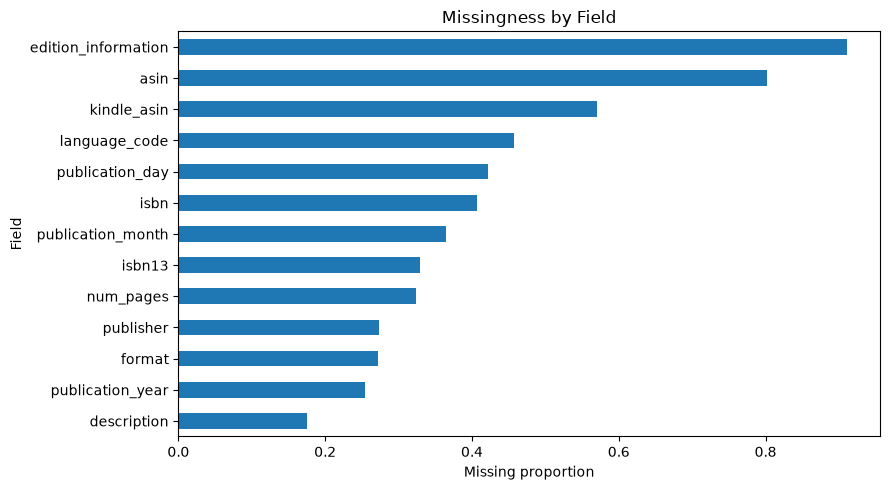

In [32]:
missing_plot = missingness.loc[missingness["missing_pct"] > 0].copy()

if not missing_plot.empty:
    ax = missing_plot.sort_values("missing_pct").plot(
        x="field",
        y="missing_pct",
        kind="barh",
        legend=False,
        figsize=(9, max(5, len(missing_plot) * 0.35)),
        title="Missingness by Field",
    )
    ax.set_xlabel("Missing proportion")
    ax.set_ylabel("Field")
    plt.tight_layout()
    plt.show()


### Key Insight

Missingness is not random: The missing-value pattern appears to have several distinct causes.

#### Structural missingness

Page counts are often missing or zero for:
* audiobooks;
* audio CDs;
* ebooks;
* Kindle editions;
* other non-print formats.

This is not ordinary missing data. In many cases, page count is not applicable.

#### Identifier-dependent missingness

ISBN and ASIN availability depend on format, publication era, and marketplace coverage.

#### Historical missingness

Older editions are more likely to have incomplete publication, publisher, language, and identifier metadata.

#### Source-system missingness

Fields such as edition_information, which is more than 91% missing, were likely inconsistently populated in Goodreads itself.

A universal imputation strategy would therefore be inappropriate. Missingness must be analyzed conditionally.

### Interpretation prompts

Classify missingness as potentially structural, format-dependent, historical, language-dependent, or unexplained. Do not impute values yet.


## 5. Descriptive statistics for numerical variables

In [38]:
numeric_summary = books[numeric_columns].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

numeric_summary["missing_pct"] = books[numeric_columns].isna().mean()
numeric_summary["zero_pct"] = books[numeric_columns].eq(0).mean()
numeric_summary["skew"] = books[numeric_columns].skew()

display(
    numeric_summary[
        [
            "count", "missing_pct", "mean", "std", "min",
            "1%", "5%", "25%", "50%", "75%", "95%", "99%",
            "max", "zero_pct", "skew",
        ]
    ].sort_values("skew", ascending=False)
)


,count,missing_pct,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,zero_pct,skew
publication_year,"3,732.0000",0.2536,"2,010.5354",303.2688,12.0000,"1,958.3100","1,983.0000","2,004.0000","2,011.0000","2,014.0000","2,016.0000","2,017.0000","20,125.0000",0.0000,57.0696
ratings_count,"5,000.0000",0.0000,374.2496,"5,279.2697",0.0000,1.0000,1.0000,6.0000,21.0000,78.0000,758.0500,"4,921.7200","296,895.0000",0.0050,41.6956
text_reviews_count,"5,000.0000",0.0000,32.5448,372.1127,0.0000,1.0000,1.0000,2.0000,4.0000,12.0000,81.0500,380.0900,"16,152.0000",0.0002,33.4948
author_count,"5,000.0000",0.0000,1.4122,1.5559,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,3.0000,6.0000,50.0000,0.0000,14.6537
num_pages,"3,381.0000",0.3238,270.2727,229.7169,0.0000,8.0000,32.0000,150.0000,246.0000,346.0000,567.0000,915.2000,"4,683.0000",0.0032,6.8715
series_count,"5,000.0000",0.0000,0.3502,0.5710,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,2.0000,4.0000,0.6868,1.8813
description_length_chars,"5,000.0000",0.0000,697.8078,604.8681,0.0000,0.0000,0.0000,235.0000,651.0000,"1,004.0000","1,694.2000","2,736.1400","6,982.0000",0.1756,1.7911
similar_book_count,"5,000.0000",0.0000,6.9106,7.9981,0.0000,0.0000,0.0000,0.0000,0.0000,17.0000,18.0000,18.0000,18.0000,0.5478,0.3906
publication_day,"2,893.0000",0.4214,12.3028,10.1702,1.0000,1.0000,1.0000,1.0000,10.0000,21.0000,30.0000,31.0000,31.0000,0.0000,0.3764
popular_shelf_count,"5,000.0000",0.0000,54.4012,41.3075,0.0000,0.0000,2.0000,11.0000,50.0000,100.0000,100.0000,100.0000,100.0000,0.0140,-0.0064


### Numerical interpretation prompts

Look for large mean–median gaps, large 99th-percentile-to-maximum gaps, structural zeros, and variables likely to benefit from `log1p`.


## 6. Plotting helpers

In [48]:
def plot_histogram(
    series: pd.Series,
    title: str,
    xlabel: str,
    bins: int = 40,
    log1p: bool = False,
) -> None:
    values = series.dropna()
    if log1p:
        values = np.log1p(values)

    ax = values.plot(
        kind="hist",
        bins=bins,
        figsize=(8, 5),
        title=title,
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Books")
    plt.tight_layout()
    plt.show()


def plot_boxplot(series: pd.Series, title: str, xlabel: str) -> None:
    values = series.dropna()
    fig, ax = plt.subplots(figsize=(8, 2.5))
    ax.boxplot(values, vert=False)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    plt.tight_layout()
    plt.show()


## 7. Ratings and engagement

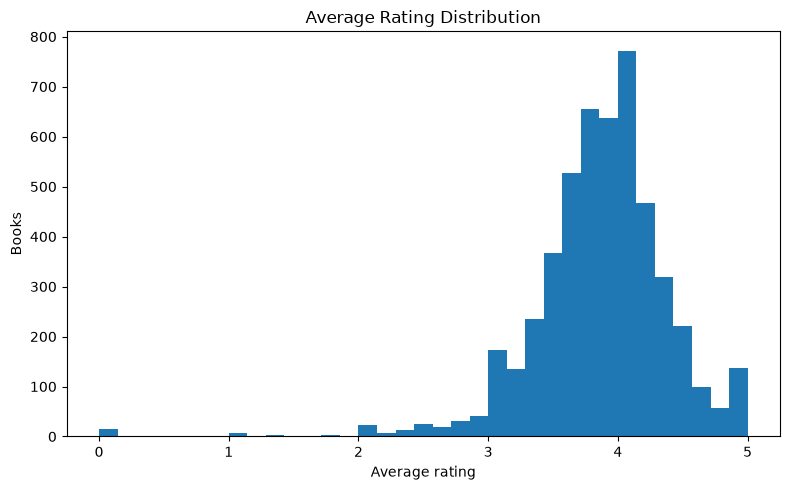

/var/folders/66/gkn4d18164jggs19kr7fl86c0000gn/T/ipykernel_34584/3436094157.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(values, vert=False)


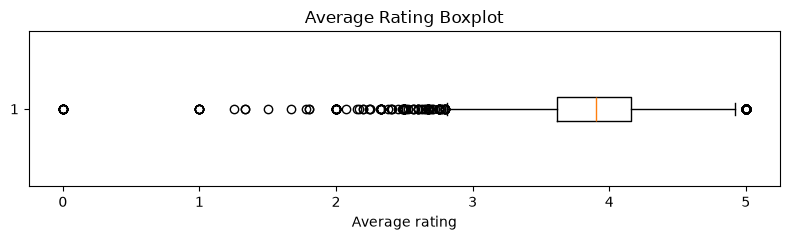

In [51]:
plot_histogram(
    books["average_rating"],
    title="Average Rating Distribution",
    xlabel="Average rating",
    bins=35,
)

plot_boxplot(
    books["average_rating"],
    title="Average Rating Boxplot",
    xlabel="Average rating",
)


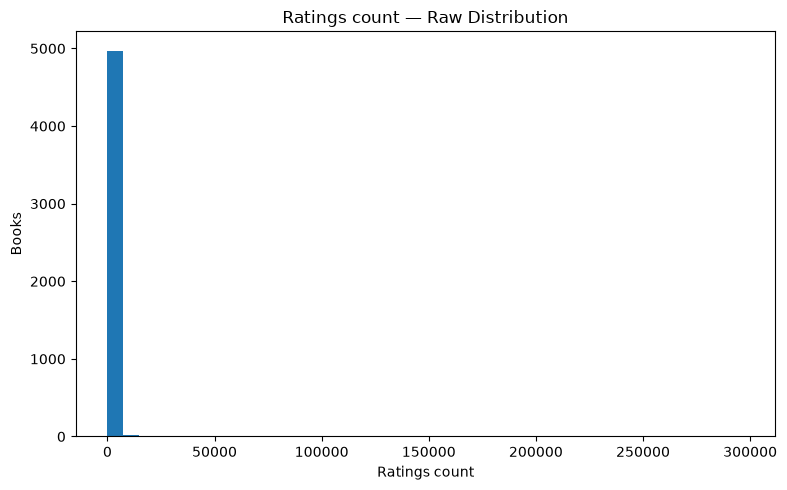

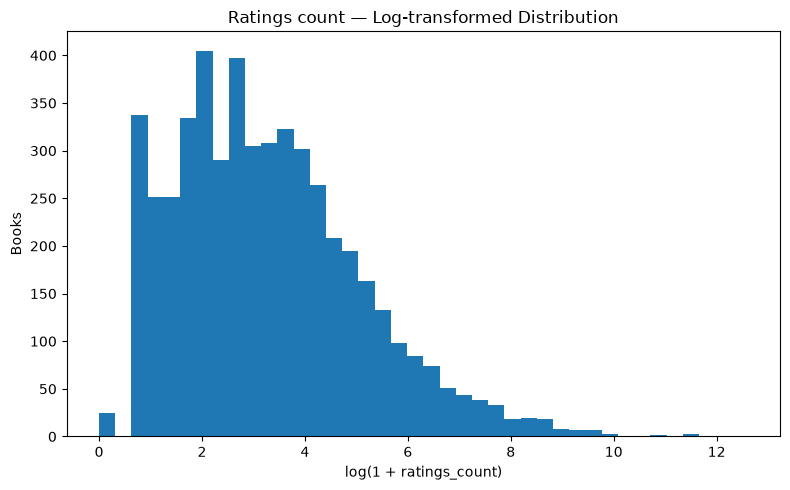

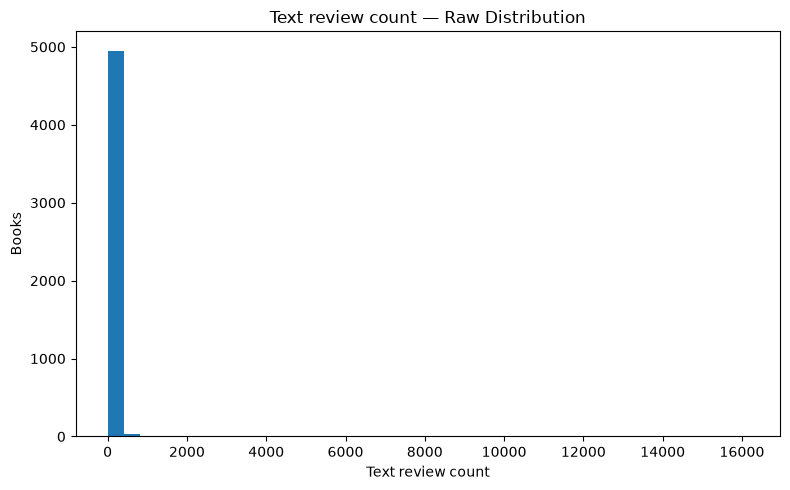

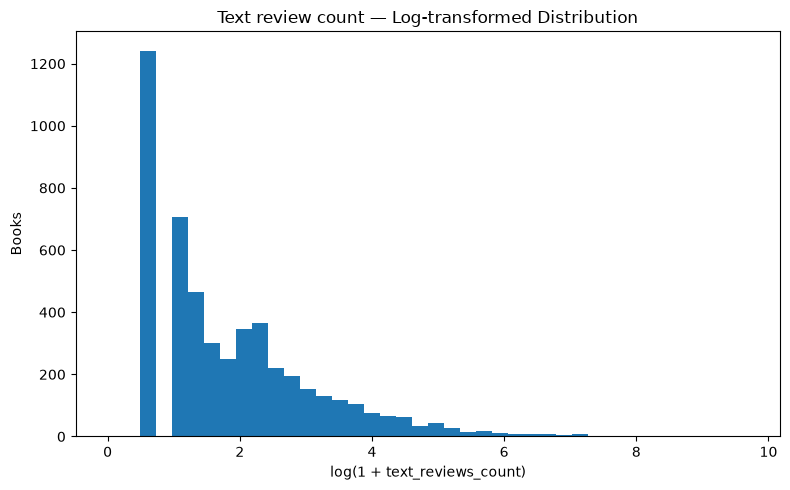

In [56]:
for column, label in [
    ("ratings_count", "Ratings count"),
    ("text_reviews_count", "Text review count"),
]:
    plot_histogram(
        books[column],
        title=f"{label} — Raw Distribution",
        xlabel=label,
        bins=40,
    )
    plot_histogram(
        books[column],
        title=f"{label} — Log-transformed Distribution",
        xlabel=f"log(1 + {column})",
        bins=40,
        log1p=True,
    )


In [63]:
threshold = CONFIG["min_ratings_for_stable_average"]

rating_reliability = pd.DataFrame({
    "group": [
        f"Fewer than {threshold} ratings",
        f"At least {threshold} ratings",
    ],
    "book_count": [
        int((books["ratings_count"] < threshold).sum()),
        int((books["ratings_count"] >= threshold).sum()),
    ],
    "mean_average_rating": [
        books.loc[books["ratings_count"] < threshold, "average_rating"].mean(),
        books.loc[books["ratings_count"] >= threshold, "average_rating"].mean(),
    ],
    "rating_std": [
        books.loc[books["ratings_count"] < threshold, "average_rating"].std(),
        books.loc[books["ratings_count"] >= threshold, "average_rating"].std(),
    ],
})

display(rating_reliability)


,group,book_count,mean_average_rating,rating_std
0,Fewer than 10 ratings,1703,3.8193,0.7563
1,At least 10 ratings,3297,3.8806,0.3810


### Key Insights

Engagement variables are extremely heavy-tailed. The clearest statistical feature of the dataset is the extreme concentration of reader engagement.

Ratings count's Statistics:
Median: 21
75th percentile: 78
95th percentile: 758
99th percentile: 4,922
Maximum: 296,895
Skew: 41.70
The Rating's mean of 374 is misleading because it is dominated by a small number of very popular books.

Text review count's Statistics:
Median: 4
75th percentile: 12
95th percentile: 81
99th percentile: 380
Maximum: 16,152
Skew: 33.49
The raw histograms are almost unusable because nearly all books are compressed near zero. The log-transformed distributions reveal meaningful structure.


### EDA decision:

Both variables should be represented with:
np.log1p(ratings_count)
np.log1p(text_reviews_count)

The raw versions may still be retained for interpretability, but most statistical and ML analysis should use the transformed versions.


### Key Insights

Average rating is not equally reliable for every book

The average rating distribution is centered near 3.9:
Mean (3.860)
Median (3.900)
Standard deviation (0.540)
25th percentile (3.620)
75th percentile (4.160)

However, the distribution is negatively skewed because low-volume records include artificial extremes such as 0.0 and 5.0.

The rating-volume comparison is particularly important:
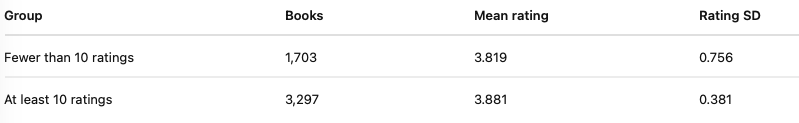

The standard deviation is approximately twice as large among low-volume books. This confirms that extreme averages are largely a small-sample problem.

### EDA decision

Future modeling should not treat all average ratings as equally reliable. Candidate strategies include:

* requiring a minimum number of ratings;
* weighting observations by rating volume;
* constructing a Bayesian or shrinkage-adjusted rating;
* predicting popularity separately from reader satisfaction.

ps.: This will be studied further in Iteration 2.


## 8. Publication year and page count

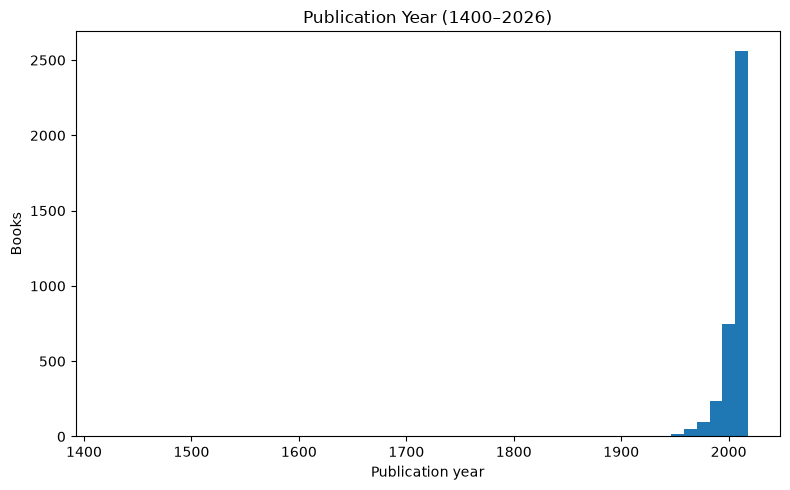

Invalid or review-required publication years: 8


,book_id,title,publication_year,format,publisher
203,17151842,Tunnel Vision: The Bomb Maker Has Arrived,12.0000,Kindle Edition,NaN
2551,32502771,Rushed,16.0000,ebook,Kerri Ann
3154,1285332,تاريخچه تقريبا همه چيز,"1,388.0000",Paperback,ntshrt mzyr
4850,18178031,تمام کودکان جهان شاعرند,"1,388.0000",Paperback,drynwsh
1330,29439484,خانه های طلا کوب آدم های نقره ای,"1,391.0000",NaN,nsym
2476,35851882,Ember Falls (The Green Ember #2),"2,916.0000",Audible Audio,Story Warren Books
2818,13616741,150 Pounds Gone Forever: How I Lost Half My Size and You Can Too,"4,012.0000",Paperback,Sunrise River Press
1768,18272325,My Crazy Purple Pen,"20,125.0000",Kindle Edition,Mark Whenham Limited


In [66]:
minimum_year = CONFIG["publication_year_min"]
current_year = CONFIG["publication_year_max"]

valid_years = books.loc[
    books["publication_year"].between(minimum_year, current_year),
    "publication_year",
]

plot_histogram(
    valid_years,
    title=f"Publication Year ({minimum_year}–{current_year})",
    xlabel="Publication year",
    bins=50,
)

invalid_years = books.loc[
    books["publication_year"].notna()
    & ~books["publication_year"].between(minimum_year, current_year),
    ["book_id", "title", "publication_year", "format", "publisher"],
].sort_values("publication_year")

print(f"Invalid or review-required publication years: {len(invalid_years):,}")
display(invalid_years)


### Key Insight

Publication year requires semantic validation, not only numeric bounds

The raw publication-year variable has extreme skew because of invalid values:

* 12
* 16
* 2916
* 4012
* 20125

However, years such as 1388 and 1391 may represent genuine historical works or editions rather than errors.
Therefore, a lower bound of 1400 is too simplistic. The revised analysis uses:

* values before 1000 as likely invalid;
* values between 1000 and the current year as potentially legitimate;
* historical periods as explicit categories;
* future years as invalid or review-required.

The distribution is heavily concentrated after 2000. This likely reflects Goodreads edition coverage rather than the historical production of literature.

### EDA decision

Publication year must be interpreted as an edition attribute, not automatically as the original work’s publication date.



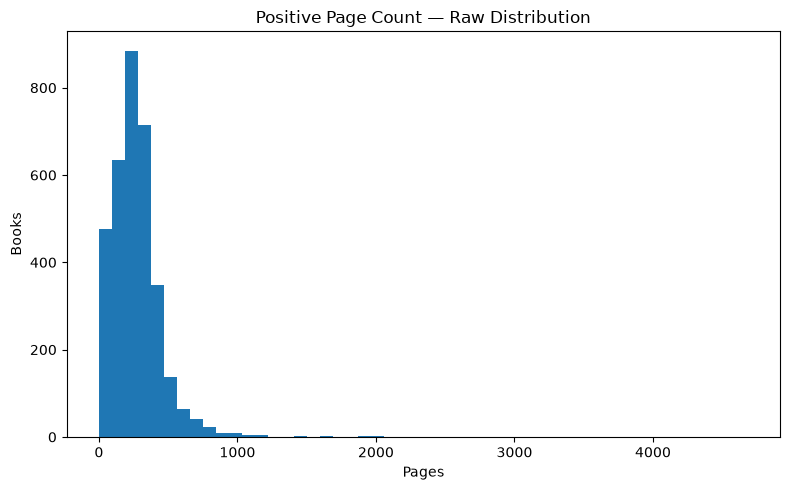

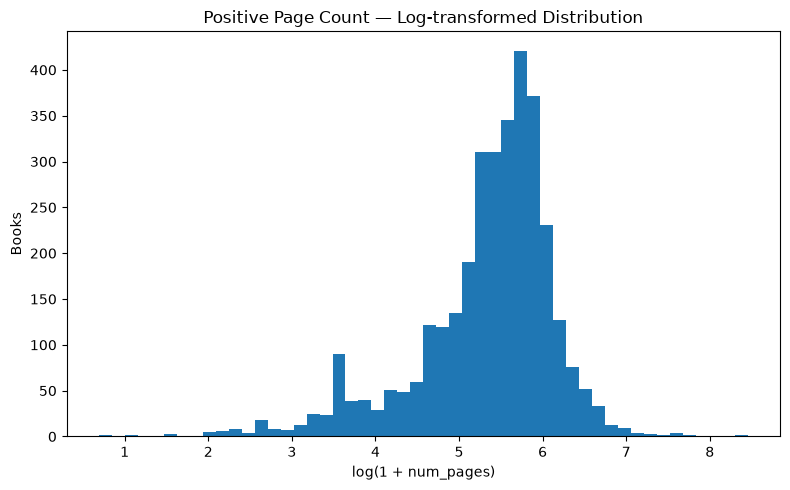

/var/folders/66/gkn4d18164jggs19kr7fl86c0000gn/T/ipykernel_34584/3436094157.py:27: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(values, vert=False)


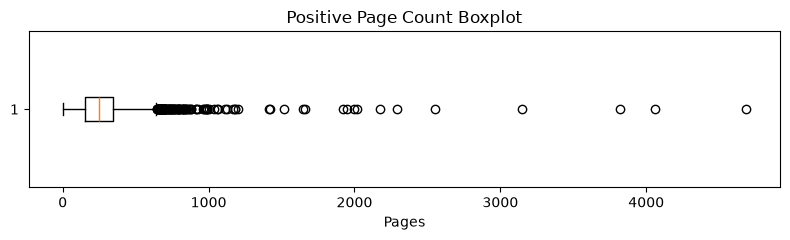

,status,book_count,share
0,Missing,1619,0.3238
1,Zero,16,0.0032
2,Positive,3365,0.6730
3,Negative,0,0.0000


In [73]:
positive_pages = books.loc[books["num_pages"] > 0, "num_pages"]

plot_histogram(
    positive_pages,
    title="Positive Page Count — Raw Distribution",
    xlabel="Pages",
    bins=50,
)
plot_histogram(
    positive_pages,
    title="Positive Page Count — Log-transformed Distribution",
    xlabel="log(1 + num_pages)",
    bins=50,
    log1p=True,
)
plot_boxplot(
    positive_pages,
    title="Positive Page Count Boxplot",
    xlabel="Pages",
)

page_count_status = pd.DataFrame({
    "status": ["Missing", "Zero", "Positive", "Negative"],
    "book_count": [
        int(books["num_pages"].isna().sum()),
        int(books["num_pages"].eq(0).sum()),
        int(books["num_pages"].gt(0).sum()),
        int(books["num_pages"].lt(0).sum()),
    ],
})
page_count_status["share"] = page_count_status["book_count"] / len(books)
display(page_count_status)


### Key Insights

Page count is usable only after cleaning

Page count has:
Coverage (67.62%)
Median (246)
95th percentile (567)
99th percentile (915)
Maximum (4,683)
Skew (6.87)

The positive values become much more interpretable after log transformation.

Only 16 populated records have zero pages, but many other records have missing page counts. The earlier record review confirms that zeros frequently correspond to audio or digital formats.

### EDA decision

Use two variables later:
num_pages_clean and page_count_missing_or_inapplicable
where num_pages_clean = num_pages.where(num_pages > 0)

This preserves the information that page count is unavailable without treating zero as a physical book length.

## 9. Description and relationship counts

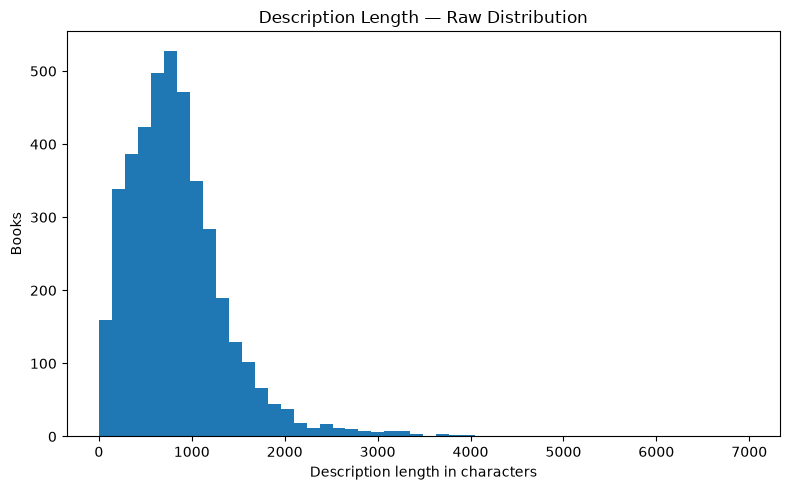

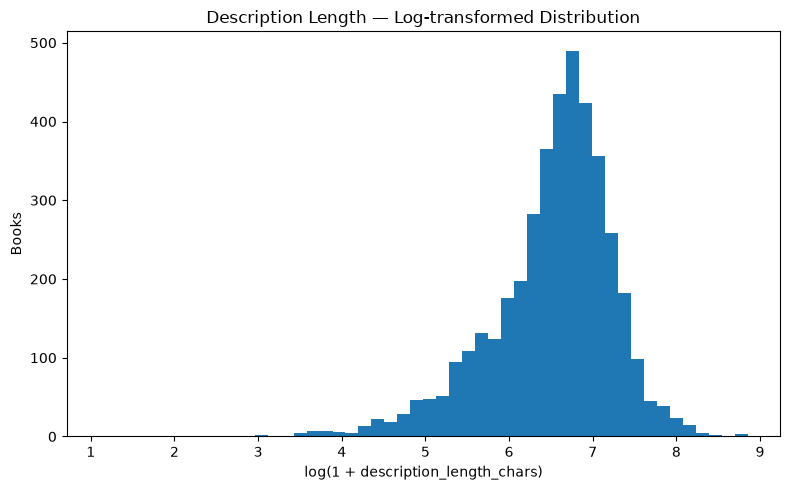

In [78]:
positive_description_lengths = books.loc[
    books["description_length_chars"] > 0,
    "description_length_chars",
]

plot_histogram(
    positive_description_lengths,
    title="Description Length — Raw Distribution",
    xlabel="Description length in characters",
    bins=50,
)
plot_histogram(
    positive_description_lengths,
    title="Description Length — Log-transformed Distribution",
    xlabel="log(1 + description_length_chars)",
    bins=50,
    log1p=True,
)


### Description length is useful but moderately skewed

Description length has:
Median (651 characters)
Mean (698 characters)
95th percentile (1,694)
99th percentile (2,736)
Maximum (6,982)
Missing/zero share (17.56%)
Skew (1.79)

The log-transformed distribution is comparatively well behaved. This variable may later function as:
* a metadata-completeness feature;
* a proxy for description richness;
* an input into text-quality filtering;



,count,mean,std,min,25%,50%,75%,max,zero_pct,skew
author_count,"5,000.0000",1.4122,1.5559,1.0000,1.0000,1.0000,1.0000,50.0000,0.0000,14.6537
series_count,"5,000.0000",0.3502,0.5710,0.0000,0.0000,0.0000,1.0000,4.0000,0.6868,1.8813
popular_shelf_count,"5,000.0000",54.4012,41.3075,0.0000,11.0000,50.0000,100.0000,100.0000,0.0140,-0.0064
similar_book_count,"5,000.0000",6.9106,7.9981,0.0000,0.0000,0.0000,17.0000,18.0000,0.5478,0.3906


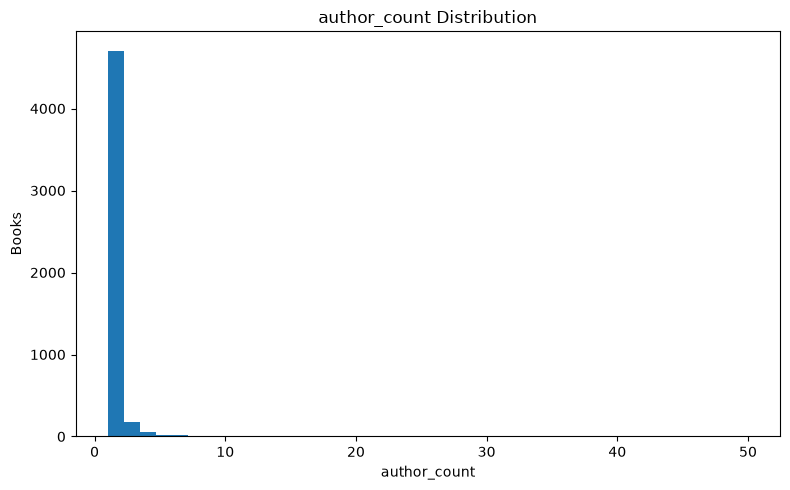

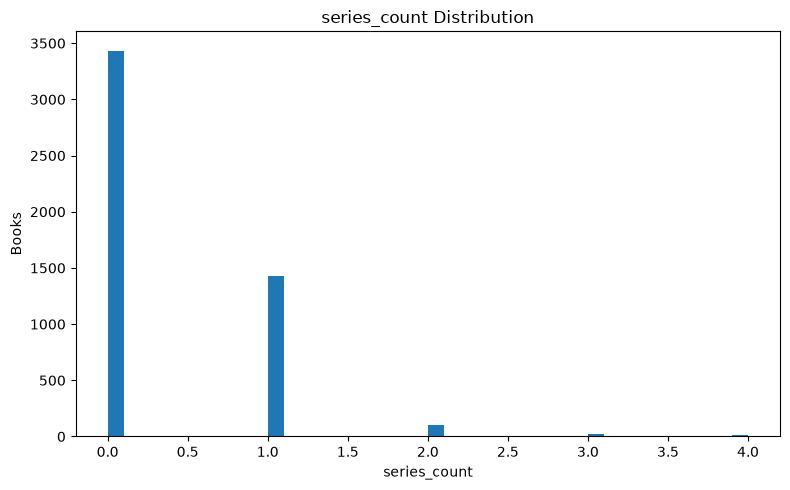

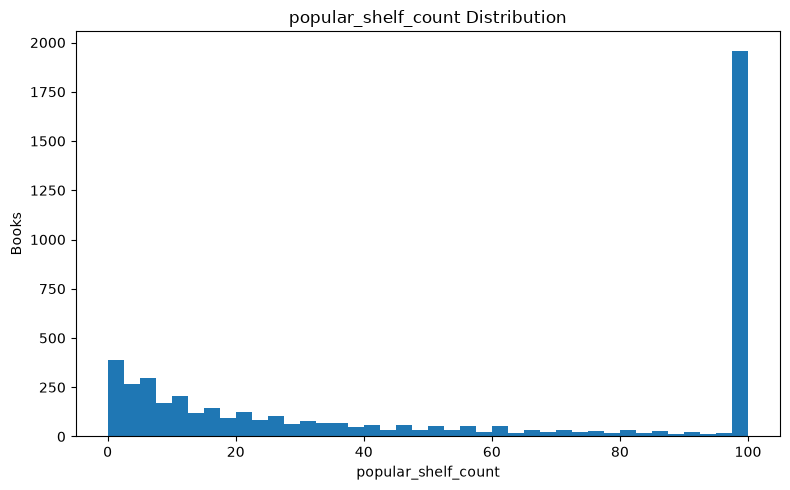

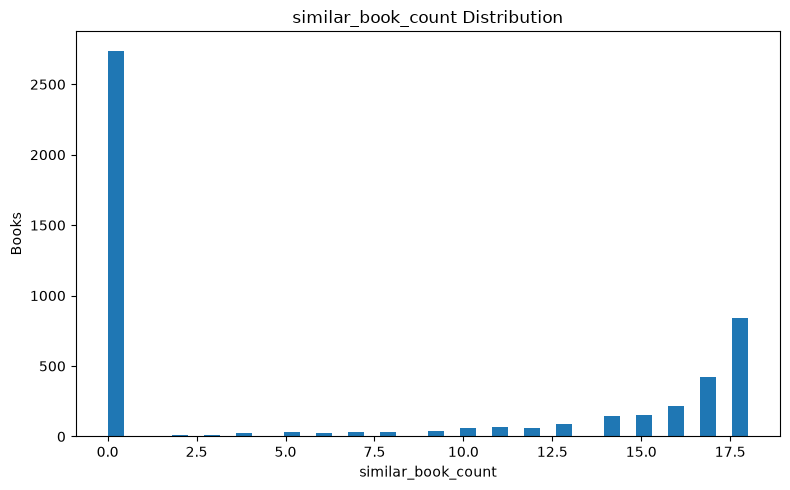

In [90]:
relationship_count_columns = [
    column
    for column in [
        "author_count",
        "series_count",
        "popular_shelf_count",
        "similar_book_count",
    ]
    if column in books.columns
]

relationship_summary = books[relationship_count_columns].describe().T
relationship_summary["zero_pct"] = books[relationship_count_columns].eq(0).mean()
relationship_summary["skew"] = books[relationship_count_columns].skew()

display(relationship_summary)

for column in relationship_count_columns:
    plot_histogram(
        books[column],
        title=f"{column} Distribution",
        xlabel=column,
        bins=40,
    )


### Key Insights

1) Relationship counts reveal source-system censoring

Two fields deserve special attention.

popular_shelf_count
* Mean: 54.4
* Median: 50
* 75th percentile: 100
* Maximum: 100
* Skew: approximately 0

The large spike at exactly 100 strongly suggests that Goodreads exported only the top 100 popular shelves.

Therefore, 100 does not mean that a book has exactly 100 shelves. It likely means:
The book has at least 100 shelf records in the exported representation.

similar_book_count

* 54.78% have zero similar books;
* the maximum is exactly 18;
* the upper distribution accumulates strongly near 18.

This also appears capped by the source dataset.

### EDA decision

These variables are right-censored. They can still be used as:

* relationship-availability indicators;
* approximate connectivity measures below the cap;
* capped count features;
* graph coverage indicators.

They should not be interpreted as complete counts.

===

2) Author count contains valid but influential outliers

Most books have one author:

* median: 1;
* 75th percentile: 1;
* 95th percentile: 3;
* 99th percentile: 6;
* maximum: 50.

The maximum likely represents anthologies, collections, encyclopedic works, or contributor-heavy editions.
The field is not necessarily erroneous, but raw values may dominate distance-based models.
Potential representations include:

* raw count;
* capped count;
* has_multiple_authors;
* log1p(author_count);
* anthology/contributor-heavy flag.


## 10. Initial categorical analysis

In [96]:
def category_summary(
    series: pd.Series,
    top_n: int = 20,
    missing_label: str = "<missing>",
) -> pd.DataFrame:
    values = series.astype("string").fillna(missing_label)
    counts = values.value_counts(dropna=False)

    result = counts.head(top_n).rename_axis("category").reset_index(name="book_count")
    result["share"] = result["book_count"] / len(series)
    return result


categorical_fields = [
    column
    for column in ["language_code", "format", "publisher", "country_code", "is_ebook"]
    if column in books.columns
]

for column in categorical_fields:
    print(f"\n{column}")
    display(category_summary(books[column], top_n=CONFIG["top_n_categories"]))



language_code


,category,book_count,share
0,<missing>,2285,0.4570
1,eng,1474,0.2948
2,en-US,206,0.0412
3,en-GB,121,0.0242
4,spa,115,0.0230
5,ita,94,0.0188
6,ara,89,0.0178
7,ger,63,0.0126
8,ind,62,0.0124
9,fre,60,0.0120



format


,category,book_count,share
0,Paperback,1945,0.3890
1,<missing>,1361,0.2722
2,Hardcover,740,0.1480
3,ebook,398,0.0796
4,Kindle Edition,270,0.0540
5,Mass Market Paperback,81,0.0162
6,Audio CD,64,0.0128
7,Audiobook,43,0.0086
8,Audible Audio,22,0.0044
9,Unknown Binding,13,0.0026



publisher


,category,book_count,share
0,<missing>,1365,0.2730
1,Createspace Independent Publishing Platform,48,0.0096
2,Harlequin,33,0.0066
3,Smashwords Edition,24,0.0048
4,Createspace,23,0.0046
5,Vintage,21,0.0042
6,HarperCollins,19,0.0038
7,Penguin Books,15,0.0030
8,Scholastic,14,0.0028
9,Brilliance Audio,14,0.0028



country_code


,category,book_count,share
0,US,5000,1.0000



is_ebook


,category,book_count,share
0,False,3569,0.7138
1,True,1431,0.2862


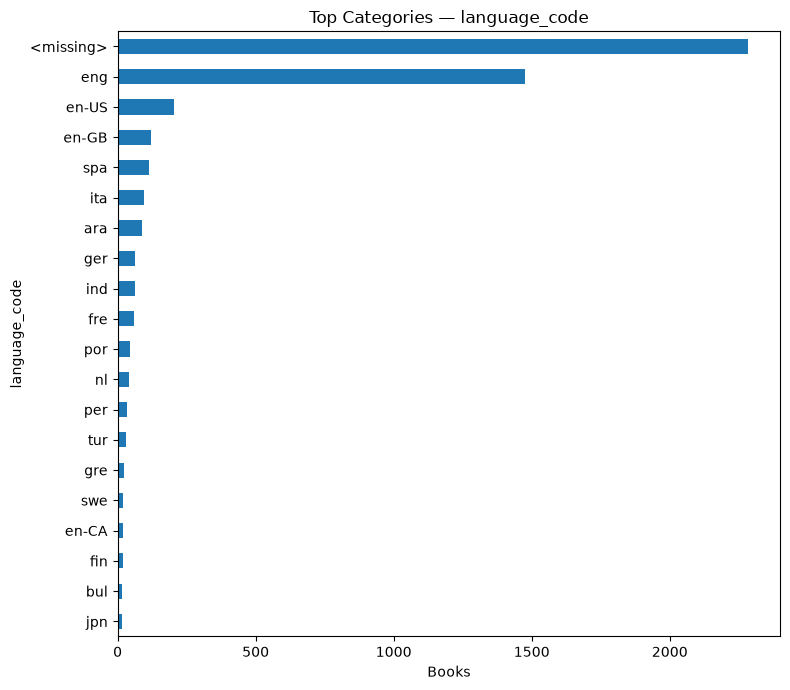

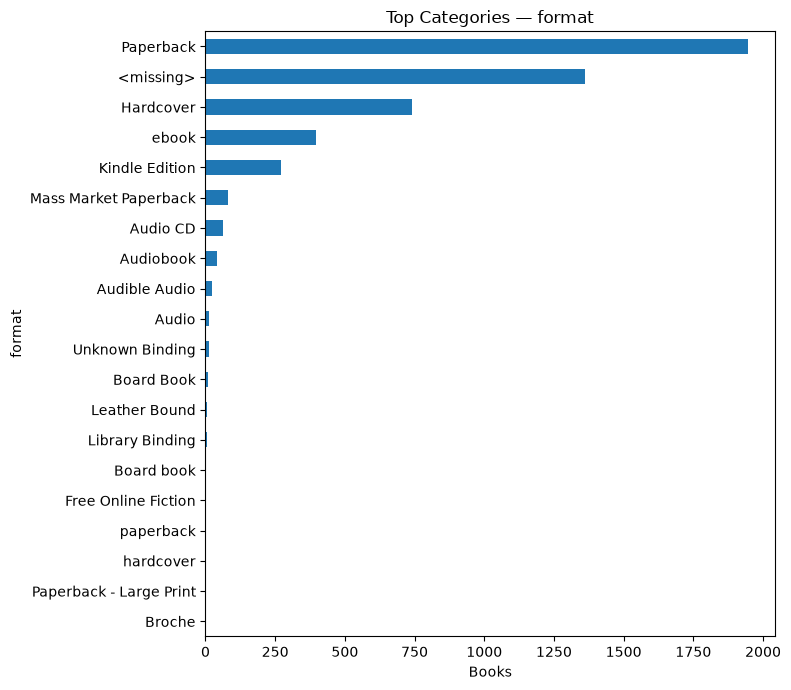

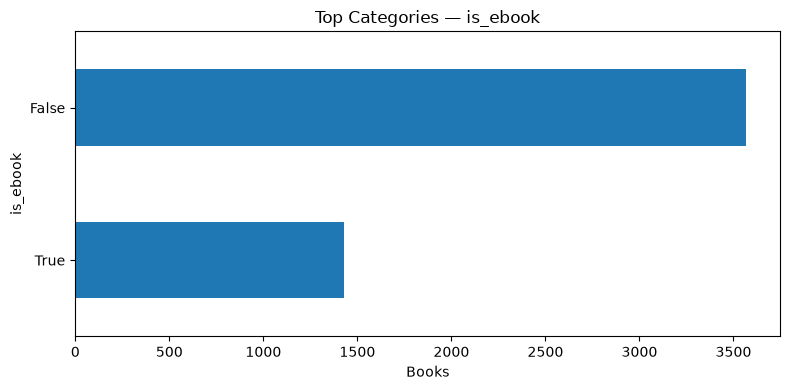

In [104]:
for column in ["language_code", "format", "is_ebook"]:
    if column not in books.columns:
        continue

    summary = category_summary(
        books[column],
        top_n=CONFIG["top_n_categories"],
    ).sort_values("book_count")

    ax = summary.plot(
        x="category",
        y="book_count",
        kind="barh",
        legend=False,
        figsize=(8, max(4, len(summary) * 0.35)),
        title=f"Top Categories — {column}",
    )
    ax.set_xlabel("Books")
    ax.set_ylabel(column)
    plt.tight_layout()
    plt.show()


###  Key Insights

#### Categorical variables require normalization

1) Language: The largest category is missing a lot of values:
Missing (45.70%)
eng (29.48%)
en-US (4.12%)
en-GB (2.42%)
spa (2.30%)

The field mixes:
* base language codes;
* regional language variants;
* several coding conventions;
* missing values.

For some analyses, eng, en-US, and en-GB may need to map to a common language family while retaining regional variants separately.

2) Format:

The format field mixes:
* physical binding;
* media type;
* digital edition type;
* print size;
* inconsistent capitalization.

Examples include:
* Paperback
* paperback
* Hardcover
* hardcover
* ebook
* Kindle Edition
* Audio CD
* Audiobook
* Mass Market Paperback

This requires canonicalization before use.

3) Publisher:

Publisher has:
* 27.3% missingness;
* 2,346 distinct populated values in only 5,000 books;
* very low concentration among the leading publishers.

This is a severe long-tail feature. Direct one-hot encoding would create excessive sparsity.

Likely alternatives include:
* frequency encoding;
* rare-publisher grouping;
* normalized publisher families;
* publisher popularity features;
* excluding raw publisher identity from simpler baseline models.

4) Country code: Every record has US. This field contains no variance in the sample and has no predictive or clustering value. It should be excluded unless a future data source introduces meaningful diversity.

5) Ebook status: Approximately 28.6% of records have is_ebook=True. The relationship between is_ebook and format should be checked for inconsistencies before either field is used.


## 11. Outlier and anomaly review

In [115]:
def top_records(
    df: pd.DataFrame,
    sort_column: str,
    display_columns: Iterable[str],
    n: int = 20,
    ascending: bool = False,
) -> pd.DataFrame:
    available = [column for column in display_columns if column in df.columns]
    return (
        df.loc[df[sort_column].notna(), available]
        .sort_values(sort_column, ascending=ascending)
        .head(n)
    )


display_columns = [
    "book_id", "title", "average_rating", "ratings_count",
    "text_reviews_count", "num_pages", "publication_year",
    "format", "language_code", "description_length_chars",
]

print("Most-rated books")
display(top_records(books, "ratings_count", display_columns))

print("Longest positive page counts")
display(top_records(books.loc[books["num_pages"] > 0], "num_pages", display_columns))

print("Longest descriptions")
display(top_records(books, "description_length_chars", display_columns))


Most-rated books


,book_id,title,average_rating,ratings_count,text_reviews_count,num_pages,publication_year,format,language_code,description_length_chars
4164,242006,Running with Scissors,3.7000,296895,10327,315.0000,NaN,NaN,eng,964
842,6366437,Half Broke Horses,4.0500,112227,9651,272.0000,"2,009.0000",Hardcover,eng,1609
188,17788401,Ugly Love,4.3000,111027,13368,337.0000,"2,014.0000",Kindle Edition,eng,741
4999,13206900,"Winter (The Lunar Chronicles, #4)",4.4900,106410,16152,827.0000,"2,015.0000",Hardcover,eng,835
3955,412732,The Dharma Bums,3.9400,63322,2011,NaN,"1,986.0000",NaN,en-US,403
2440,8204005,"Love Unscripted (Love, #1)",4.0400,59594,3021,NaN,NaN,NaN,en-US,1094
4358,22285,Rant,3.8200,49817,2413,320.0000,"2,007.0000",Hardcover,en-US,393
922,4656,The Fourth Hand,3.3000,23544,886,368.0000,"2,003.0000",Paperback,eng,545
1931,383514,"Her Royal Spyness (Her Royal Spyness Mysteries, #1)",3.7700,18010,1920,NaN,NaN,NaN,eng,531
855,7775611,"Thirst No. 3: The Eternal Dawn (Thirst, #3)",4.1400,17522,389,478.0000,"2,010.0000",Paperback,en-US,717


Longest positive page counts


,book_id,title,average_rating,ratings_count,text_reviews_count,num_pages,publication_year,format,language_code,description_length_chars
281,25977566,منحة العلام في شرح بلوغ المرام,3.8300,6,1,"4,683.0000",NaN,Paperback,ara,0
900,34039495,"Prowlers & Growlers: A Paranormal Romance & Urban Fantasy Collection of Alpha Vampires, Werewolves, Dragon Shifters,...",4.4600,36,23,"4,060.0000","2,017.0000",Kindle Edition,NaN,389
2563,18196045,The Stories: Five Years of Original Fiction on Tor.com,3.8500,48,14,"3,817.0000","2,013.0000",ebook,eng,6982
3670,825632,Nelson Textbook of Pediatrics,4.2200,195,14,"3,147.0000","2,007.0000",Hardcover,NaN,615
2630,243900,A Dream of Red Mansions,4.1200,161,25,"2,549.0000",NaN,NaN,eng,1916
4132,805777,Ryrie Study Bible Expanded Edition- New American Standard Bible,4.6800,93,10,"2,292.0000","1,995.0000",Hardcover,NaN,296
1408,5486988,Oeuvres Completes,5.0000,1,1,"2,176.0000","1,996.0000",Leather Bound,fre,0
2054,17334192,The Rot Ruin Collection: Rot Ruin; Dust Decay; Flesh Bone; Fire Ash,4.6400,94,7,"2,016.0000","2,013.0000",Hardcover,NaN,591
4975,18777016,تاريخ الجزائر العام,4.0800,36,2,"2,000.0000","1,983.0000",Hardcover,ara,234
3541,53948,Holy Bible: Reformation Study Bible,4.6600,930,62,"1,948.0000","2,005.0000",Hardcover,eng,1705


Longest descriptions


,book_id,title,average_rating,ratings_count,text_reviews_count,num_pages,publication_year,format,language_code,description_length_chars
2563,18196045,The Stories: Five Years of Original Fiction on Tor.com,3.8500,48,14,"3,817.0000","2,013.0000",ebook,eng,6982
2285,12174725,Don't Vote!: It Just Encourages the Bastards,3.5800,6,3,277.0000,"2,011.0000",Paperback,eng,6446
617,3744216,Social Computing with Microsoft Sharepoint 2007: Implementing Applications for Sharepoint to Enable Collaboration an...,3.5000,2,1,377.0000,"2,009.0000",Paperback,NaN,6161
2848,13268113,The Story of THE RAG!,3.5000,11,6,310.0000,"2,011.0000",Paperback,NaN,5619
242,28115776,পলাতক তুফান,4.3300,7,4,NaN,"1,921.0000",NaN,ben,4762
1721,22729615,Кучки вероломни,3.8500,40,12,230.0000,"2,015.0000",Paperback,bul,4543
4822,20982008,All Against The Law,4.0000,7,3,844.0000,"2,014.0000",ebook,NaN,3980
2235,13017390,This Brilliant Darkness,3.6800,87,28,316.0000,"2,011.0000",Paperback,eng,3980
1695,23603466,Dominant Couples submissive women,3.2000,5,1,163.0000,"2,014.0000",ebook,en-US,3872
1786,20486263,When A Woman Loves,4.5000,1,1,NaN,"2,014.0000",ebook,eng,3780


## 12. Iteration 1 checkpoint

After running the notebook through this point, focused on following insigts (specific insights are captured below each (or set of) variables:
1. Dataset shape, memory usage, and optional tables loaded.
2. Missingness table and plot.
3. Numerical summary, especially skew and extreme percentiles.
4. Rating distributions and low-versus-higher rating-count comparison.
5. Publication-year and page-count outputs.
6. Description-length and relationship-count summaries.
7. Top category tables for language, format, publisher, country, and ebook status.
8. Notable outlier records.


### Sample-size decision

The 5,000-record sample is sufficient to:
* identify data-quality patterns;
* design transformations;
* discover source caps;
* prototype EDA code;
* determine candidate features.

It is not yet large enough to confidently estimate:
* rare language distributions;
* rare format relationships;
* publisher concentration;
* edition duplication at the work level;
* similar-book graph properties.

While I decided to continue the iteration 2 with 5K books, eventually, I may choose to increase the sample size to 25K books



## Next EDA Iteration

The next analysis should focus on seven questions.

1. Rating reliability

Analyze average-rating variance and exact extremes across increasingly large rating-count bands.

==

2. Engagement relationships

Compare raw Pearson correlations with rank-based Spearman correlations for:
* ratings;
* text reviews;
* shelves;
* similar-book connections.

==

3. Multivariate relationships

Study whether:
* longer descriptions correlate with popularity;
* page count correlates with ratings;
* recent editions receive more engagement;
* series membership affects popularity;
* author count affects average rating.

==

4. Conditional missingness

Measure whether missing fields depend on:

* format;
* ebook status;
* publication period;
* language.

==

5. Categorical concentration

Quantify:
* top-category concentration;
* singleton counts;
* case and whitespace aliases;
* long-tail severity.

==

6. Edition versus work analysis

Inspect books sharing a work_id to determine whether editions differ in:
* rating;
* popularity;
* language;
* format;
* publication year.

==

7. Similar-book graph diagnostics

Evaluate:
* edge count;
* graph coverage;
* self-loops;
* directional symmetry;
* whether the source recommendations are reciprocal.


*********

********

# Iteration 2 — Multivariate EDA and analytical decisions

Iteration 1 revealed several important properties:

- engagement counts are extremely right-skewed;
- average ratings become more stable as rating volume increases;
- page counts and publication fields contain structural missingness and anomalies;
- `popular_shelf_count` and `similar_book_count` appear capped by the source data;
- categorical fields contain missing values, aliases, and long tails;
- the 5,000-row sample contains a small number of repeated `work_id` values.

This iteration examines relationships, conditional missingness, censoring, edition-versus-work behavior, categorical consistency, and transformation choices. Permanent features will be formalized in Notebook 03.

## 13. Resolve optional-table filename aliases

In [239]:
similar_book_candidates = [
    INTERIM_DIR / "book_similarities_sample.parquet",
    INTERIM_DIR / "book_similar_books_sample.parquet",
]

similar_books_path = next(
    (path for path in similar_book_candidates if path.exists()),
    None,
)

if similar_books_path is not None:
    optional_tables["similar_books"] = pd.read_parquet(similar_books_path)
    print(f"Loaded similar-book edges from: {similar_books_path.name}")
    print(f"Shape: {optional_tables['similar_books'].shape}")
    display(optional_tables["similar_books"].head())
else:
    print("No similar-book edge file found under either expected filename.")


Loaded similar-book edges from: book_similarities_sample.parquet
Shape: (34553, 2)


,source_book_id,similar_book_id
0,3329556,3113
1,3329556,607413
2,3329556,514565
3,3329556,795301
4,3329556,7258212


## 14. Create EDA-only analytical variables

In [136]:
eda = books.copy()
current_year = pd.Timestamp.now().year

# Treating years before 1000 or after the current year as invalid
# Retaining  medieval/early historical years for separate review

eda["publication_year_valid"] = eda["publication_year"].where(
    eda["publication_year"].between(1000, current_year)
)

eda["publication_period"] = pd.cut(
    eda["publication_year_valid"],
    bins=[999, 1799, 1899, 1949, 1999, current_year],
    labels=[
        "Before 1800",
        "1800–1899",
        "1900–1949",
        "1950–1999",
        "2000+",
    ],
)

eda["edition_age"] = current_year - eda["publication_year_valid"]

# Zero pages are treated as unavailable/inapplicable in numeric analysis

eda["num_pages_clean"] = eda["num_pages"].where(eda["num_pages"] > 0)

# Heavy-tailed variables.
for column in [
    "ratings_count",
    "text_reviews_count",
    "description_length_chars",
    "popular_shelf_count",
    "similar_book_count",
]:
    if column in eda.columns:
        eda[f"log1p_{column}"] = np.log1p(eda[column])

eda["log1p_num_pages"] = np.log1p(eda["num_pages_clean"])

# Source-censoring flags observed in Iteration 1

eda["popular_shelves_at_cap"] = eda["popular_shelf_count"].eq(
    eda["popular_shelf_count"].max()
)
eda["similar_books_at_cap"] = eda["similar_book_count"].eq(
    eda["similar_book_count"].max()
)

# Rating-volume bands

rating_bins = [-1, 0, 4, 9, 49, 99, 999, np.inf]

rating_labels = ["0", "1–4", "5–9", "10–49", "50–99", "100–999", "1,000+"]

eda["rating_count_band"] = pd.cut(
    eda["ratings_count"],
    bins=rating_bins,
    labels=rating_labels,
)

# Work multiplicity in this sample

eda["editions_in_sample_for_work"] = (
    eda.groupby("work_id")["book_id"].transform("nunique")
)
eda["work_has_multiple_editions"] = (
    eda["editions_in_sample_for_work"] > 1
)

display(
    eda[
        [
            "book_id", "work_id", "publication_year",
            "publication_year_valid", "publication_period",
            "num_pages", "num_pages_clean", "ratings_count",
            "log1p_ratings_count", "rating_count_band",
            "popular_shelves_at_cap", "similar_books_at_cap",
            "editions_in_sample_for_work",
        ]
    ].head()
)


,book_id,work_id,publication_year,publication_year_valid,publication_period,num_pages,num_pages_clean,ratings_count,log1p_ratings_count,rating_count_band,popular_shelves_at_cap,similar_books_at_cap,editions_in_sample_for_work
0,3329556,190264,"2,008.0000","2,008.0000",2000+,304.0000,304.0000,164,5.1059,100–999,True,False,1
1,7745509,7418432,"2,010.0000","2,010.0000",2000+,0.0000,NaN,2,1.0986,1–4,True,False,1
2,22877544,42442882,"1,965.0000","1,965.0000",1950–1999,254.0000,254.0000,1,0.6931,1–4,False,False,1
3,22779170,24946905,"2,014.0000","2,014.0000",2000+,455.0000,455.0000,7,2.0794,5–9,True,True,1
4,17536094,7002929,"2,011.0000","2,011.0000",2000+,208.0000,208.0000,5,1.7918,5–9,True,False,1


## 15. Diagnose capped and structurally constrained variables

If many records sit exactly at a hard maximum, the variable is likely right-censored by the source extraction process. Such a field can still indicate presence or relative richness below the cap, but its maximum should not be interpreted as a complete real-world count.

In [141]:
cap_summary = pd.DataFrame([
    {
        "field": "popular_shelf_count",
        "observed_max": eda["popular_shelf_count"].max(),
        "books_at_max": int(eda["popular_shelves_at_cap"].sum()),
        "share_at_max": eda["popular_shelves_at_cap"].mean(),
    },
    {
        "field": "similar_book_count",
        "observed_max": eda["similar_book_count"].max(),
        "books_at_max": int(eda["similar_books_at_cap"].sum()),
        "share_at_max": eda["similar_books_at_cap"].mean(),
    },
])

display(cap_summary)


,field,observed_max,books_at_max,share_at_max
0,popular_shelf_count,100,1948,0.3896
1,similar_book_count,18,841,0.1682


### Key Insights

These are not complete natural counts. They are truncated by the Goodreads extraction design.

This explains several observations:

* popular_shelf_count has almost zero skew despite being a relationship count;
* it has a spike at exactly 100;
* similar_book_count stops abruptly at 18;
* the two variables have a high Spearman correlation of 0.761.

They likely measure a combination of:

* metadata richness;
* source-system coverage;
* popularity;
* whether the book reached the export limit.

#### Feature-engineering implications:

Keep the counts, but explicitly add:
popular_shelves_at_cap
similar_books_at_cap
has_popular_shelves = popular_shelf_count > 0
has_similar_books = similar_book_count > 0

Keeo in context to avoid interpret a value of 100 as meaning exactly 100 shelves.
For example, popular_shelf_count = 100, really means something closer to at least 100 recorded popular shelves.




## 16. Rating reliability across engagement bands

In [147]:
rating_band_summary = (
    eda.groupby("rating_count_band", observed=False)
    .agg(
        books=("book_id", "count"),
        mean_rating=("average_rating", "mean"),
        median_rating=("average_rating", "median"),
        rating_std=("average_rating", "std"),
        min_rating=("average_rating", "min"),
        max_rating=("average_rating", "max"),
        median_ratings_count=("ratings_count", "median"),
    )
    .reset_index()
)

rating_band_summary["share"] = rating_band_summary["books"] / len(eda)
display(rating_band_summary)


,rating_count_band,books,mean_rating,median_rating,rating_std,min_rating,max_rating,median_ratings_count,share
0,0,25,1.5500,0.0000,1.9645,0.0000,5.0000,0.0000,0.0050
1,1–4,1020,3.8600,3.9600,0.7405,1.0000,5.0000,2.0000,0.2040
2,5–9,658,3.8425,3.8800,0.5398,1.3300,5.0000,7.0000,0.1316
3,10–49,1660,3.8651,3.8900,0.4079,1.8000,5.0000,21.0000,0.3320
4,50–99,570,3.8658,3.8800,0.3859,2.3200,4.8600,68.0000,0.1140
5,100–999,862,3.9046,3.9000,0.3357,2.5300,4.8000,213.0000,0.1724
6,"1,000+",205,3.9466,3.9700,0.3030,2.4900,4.6300,"2,305.0000",0.0410


### Key Insights

This is strong evidence that a 5.0 rating from two readers is not comparable to a 4.0 rating from 10,000 readers.

There is also a small internal inconsistency: some books with ratings_count == 0 still have nonzero average_rating or written reviews. This could be caused by differences in how Goodreads snapshots or aggregates its fields.

### Feature-engineering implications:

Retain:
average_rating
ratings_count
log1p_ratings_count

Add:
has_ratings = ratings_count > 0
low_rating_confidence = ratings_count < 10
rating_count_band

More exploration needed in Feature Engineering to see if there are other weighted ratings that are effective


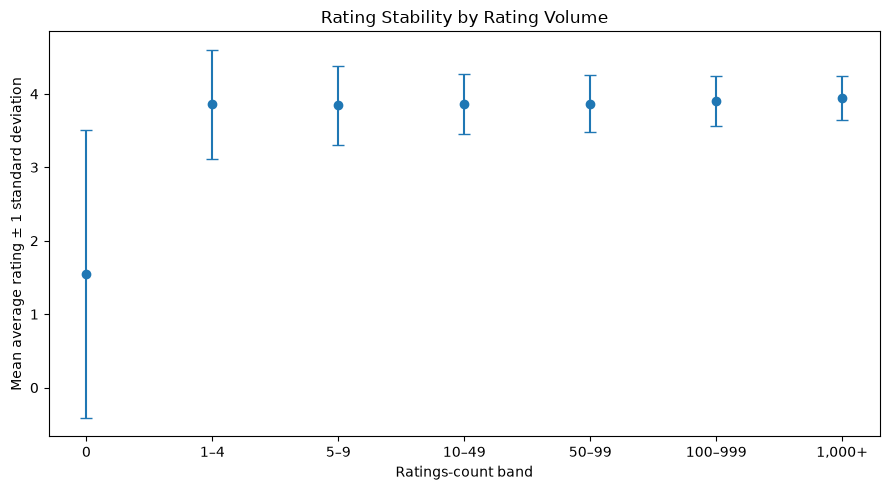

In [155]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(rating_band_summary))

ax.errorbar(
    x,
    rating_band_summary["mean_rating"],
    yerr=rating_band_summary["rating_std"],
    fmt="o",
    capsize=4,
)
ax.set_xticks(x)
ax.set_xticklabels(rating_band_summary["rating_count_band"].astype(str))
ax.set_xlabel("Ratings-count band")
ax.set_ylabel("Mean average rating ± 1 standard deviation")
ax.set_title("Rating Stability by Rating Volume")
plt.tight_layout()
plt.show()


In [160]:
extreme_rating_by_band = (
    eda.assign(exact_extreme_rating=eda["average_rating"].isin([0, 5]))
    .groupby("rating_count_band", observed=False)
    .agg(
        books=("book_id", "count"),
        extreme_rating_books=("exact_extreme_rating", "sum"),
    )
    .reset_index()
)

extreme_rating_by_band["extreme_share"] = (
    extreme_rating_by_band["extreme_rating_books"]
    / extreme_rating_by_band["books"]
)

display(extreme_rating_by_band)


,rating_count_band,books,extreme_rating_books,extreme_share
0,0,25,16,0.6400
1,1–4,1020,113,0.1108
2,5–9,658,11,0.0167
3,10–49,1660,2,0.0012
4,50–99,570,0,0.0000
5,100–999,862,0,0.0000
6,"1,000+",205,0,0.0000


## 17. Engagement relationships — Pearson versus Spearman

In [168]:
engagement_columns = [
    "ratings_count",
    "text_reviews_count",
    "popular_shelf_count",
    "similar_book_count",
]
engagement_columns = [c for c in engagement_columns if c in eda.columns]

print("Pearson correlation — raw counts")
display(eda[engagement_columns].corr(method="pearson"))

print("Spearman correlation — rank relationships")
display(eda[engagement_columns].corr(method="spearman"))


Pearson correlation — raw counts


,ratings_count,text_reviews_count,popular_shelf_count,similar_book_count
ratings_count,1.0000,0.8256,0.0731,0.0740
text_reviews_count,0.8256,1.0000,0.0834,0.0856
popular_shelf_count,0.0731,0.0834,1.0000,0.7782
similar_book_count,0.0740,0.0856,0.7782,1.0000


Spearman correlation — rank relationships


,ratings_count,text_reviews_count,popular_shelf_count,similar_book_count
ratings_count,1.0000,0.8652,0.5582,0.3993
text_reviews_count,0.8652,1.0000,0.4987,0.3738
popular_shelf_count,0.5582,0.4987,1.0000,0.7605
similar_book_count,0.3993,0.3738,0.7605,1.0000


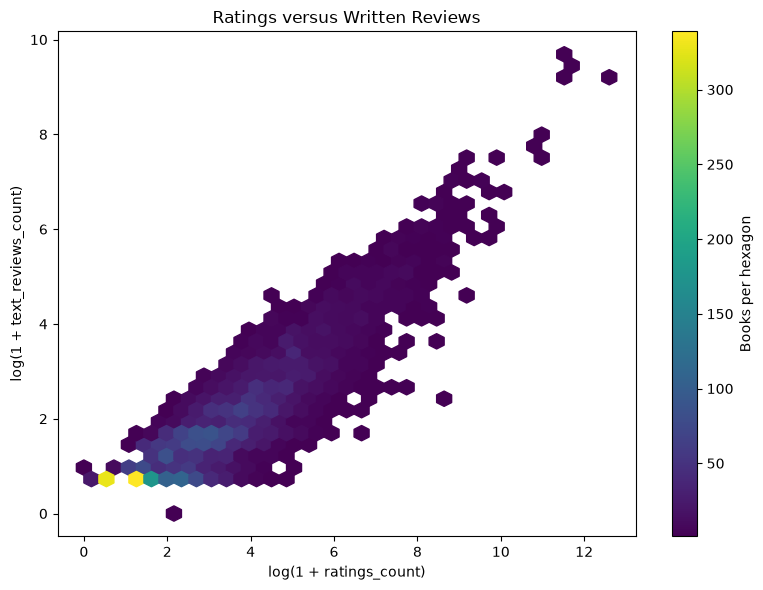

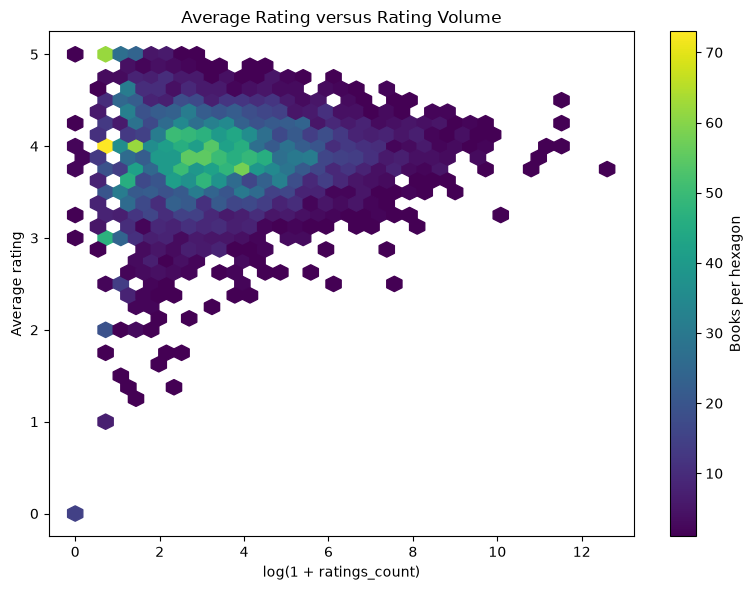

In [174]:
fig, ax = plt.subplots(figsize=(8, 6))
hb = ax.hexbin(
    eda["log1p_ratings_count"],
    eda["log1p_text_reviews_count"],
    gridsize=35,
    mincnt=1,
)

ax.set_xlabel("log(1 + ratings_count)")
ax.set_ylabel("log(1 + text_reviews_count)")
ax.set_title("Ratings versus Written Reviews")
fig.colorbar(hb, ax=ax, label="Books per hexagon")
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(8, 6))
hb = ax.hexbin(
    eda["log1p_ratings_count"],
    eda["average_rating"],
    gridsize=35,
    mincnt=1,
)

ax.set_xlabel("log(1 + ratings_count)")
ax.set_ylabel("Average rating")
ax.set_title("Average Rating versus Rating Volume")
fig.colorbar(hb, ax=ax, label="Books per hexagon")
plt.tight_layout()
plt.show()


### Key Insights

1) Popularity and satisfaction are different concepts

average_rating has only weak correlations with the other variables:

* publication year: 0.133
* page count: 0.114
* series count: 0.117
* ratings volume: 0.028
* shelf coverage: −0.044
* similar-book count: −0.027

This indicates that reader satisfaction and popularity are distinct.

A book can be:

* widely read but moderately rated;
* obscure but highly rated;
* heavily shelved but not better reviewed;
* recent and well documented without being popular.

#### Feature-engineering implications:

Do not create one broad “book quality” variable that mixes: average rating + rating volume + reviews + shelves

Instead, create separate feature families:

Satisfaction

* average rating;
* confidence-adjusted rating;
* rating dispersion, if later available.

Engagement/popularity

* ratings count;
* text review count;
* shelf signals;
* interaction counts.

This separation will also matter when defining future prediction targets.

Ratings count and review count largely measure the same latent construct

The relationship between ratings and written reviews is extremely strong:


**********

### Key Insights

Ratings count and review count largely measure the same latent construct

The relationship between ratings and written reviews is extremely strong:
Pearson: 0.826
Spearman: 0.865

This means both variables largely measure a common latent concept: Reader engagement or book popularity
However, they are not identical. Reviews represent a higher-effort form of engagement.

#### Feature-engineering implications:

Create:
log1p_ratings_count
log1p_text_reviews_count

Also, consider:
review_conversion_rate = text_reviews_count / ratings_count
with carefull handling of zero ratings:
review_conversion_rate = np.where(
    ratings_count > 0,
    text_reviews_count / ratings_count,
    np.nan,
)

This may capture the propensity of readers to write reviews rather than merely rate the book.

Because the two counts are strongly correlated, linear models may experience multicollinearity. Options include:
* retain both with regularization;
* choose one for a simple baseline;
* combine them into an engagement index;
* use PCA later to discover a latent popularity dimension.



## 18. Analytical correlation matrix

In [181]:
analysis_columns = [
    "average_rating",
    "log1p_ratings_count",
    "log1p_text_reviews_count",
    "publication_year_valid",
    "edition_age",
    "num_pages_clean",
    "log1p_num_pages",
    "description_length_chars",
    "log1p_description_length_chars",
    "author_count",
    "series_count",
    "popular_shelf_count",
    "similar_book_count",
]
analysis_columns = [c for c in analysis_columns if c in eda.columns]

spearman_matrix = eda[analysis_columns].corr(method="spearman")
display(spearman_matrix.round(3))


,average_rating,log1p_ratings_count,log1p_text_reviews_count,publication_year_valid,edition_age,num_pages_clean,log1p_num_pages,description_length_chars,log1p_description_length_chars,author_count,series_count,popular_shelf_count,similar_book_count
average_rating,1.0000,0.0280,0.0570,0.1330,-0.1330,0.1140,0.1140,0.0560,0.0560,0.0320,0.1170,-0.0440,-0.0270
log1p_ratings_count,0.0280,1.0000,0.8650,-0.0680,0.0680,0.1560,0.1560,0.1610,0.1610,-0.0080,0.2390,0.5580,0.3990
log1p_text_reviews_count,0.0570,0.8650,1.0000,0.1040,-0.1040,0.1350,0.1350,0.2120,0.2120,-0.0420,0.1930,0.4990,0.3740
publication_year_valid,0.1330,-0.0680,0.1040,1.0000,-1.0000,0.0060,0.0060,0.2760,0.2760,-0.0640,0.1040,-0.0340,-0.0110
edition_age,-0.1330,0.0680,-0.1040,-1.0000,1.0000,-0.0060,-0.0060,-0.2760,-0.2760,0.0640,-0.1040,0.0340,0.0110
num_pages_clean,0.1140,0.1560,0.1350,0.0060,-0.0060,1.0000,1.0000,0.2470,0.2470,-0.0470,0.1150,0.2420,0.2270
log1p_num_pages,0.1140,0.1560,0.1350,0.0060,-0.0060,1.0000,1.0000,0.2470,0.2470,-0.0470,0.1150,0.2420,0.2270
description_length_chars,0.0560,0.1610,0.2120,0.2760,-0.2760,0.2470,0.2470,1.0000,1.0000,-0.0000,0.0990,0.2700,0.2410
log1p_description_length_chars,0.0560,0.1610,0.2120,0.2760,-0.2760,0.2470,0.2470,1.0000,1.0000,-0.0000,0.0990,0.2700,0.2410
author_count,0.0320,-0.0080,-0.0420,-0.0640,0.0640,-0.0470,-0.0470,-0.0000,-0.0000,1.0000,0.0170,0.0870,0.0450


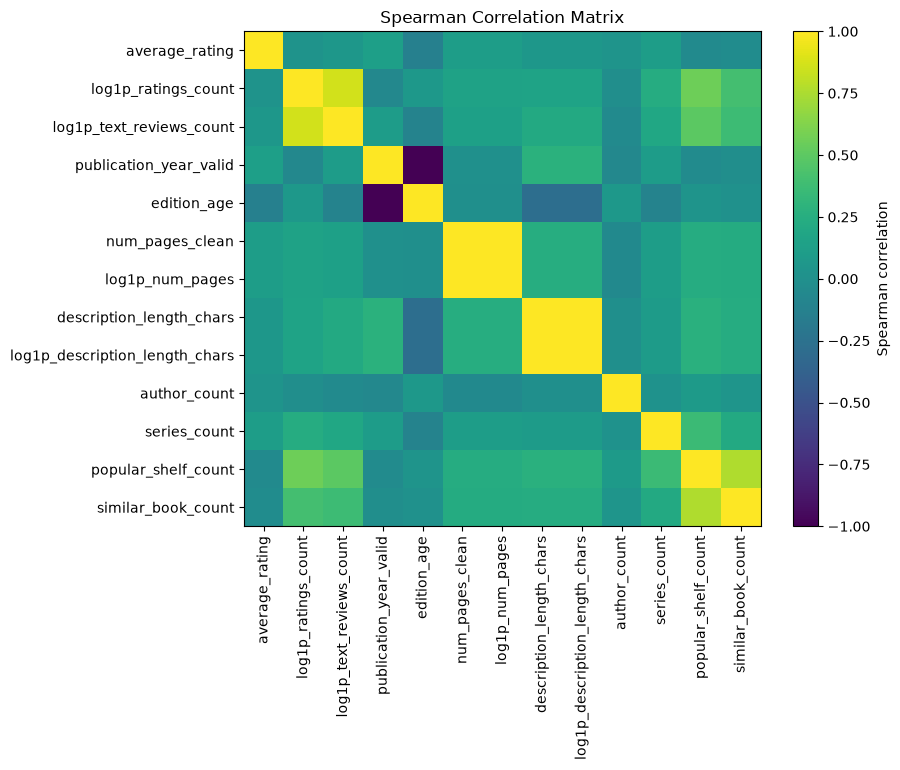

In [184]:
fig, ax = plt.subplots(
    figsize=(max(9, len(analysis_columns) * 0.7),
             max(7, len(analysis_columns) * 0.6))
)

image = ax.imshow(spearman_matrix, aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(analysis_columns)))
ax.set_yticks(range(len(analysis_columns)))
ax.set_xticklabels(analysis_columns, rotation=90)
ax.set_yticklabels(analysis_columns)
ax.set_title("Spearman Correlation Matrix")
fig.colorbar(image, ax=ax, label="Spearman correlation")
plt.tight_layout()
plt.show()


In [189]:
correlation_pairs = (
    spearman_matrix.where(
        np.triu(np.ones(spearman_matrix.shape), k=1).astype(bool)
    )
    .stack()
    .rename("spearman_correlation")
    .reset_index()
    .rename(columns={"level_0": "variable_1", "level_1": "variable_2"})
)

correlation_pairs["absolute_correlation"] = (
    correlation_pairs["spearman_correlation"].abs()
)

display(
    correlation_pairs.sort_values(
        "absolute_correlation",
        ascending=False,
    ).head(20)
)


,variable_1,variable_2,spearman_correlation,absolute_correlation
71,num_pages_clean,log1p_num_pages,1.0000,1.0000
43,publication_year_valid,edition_age,-1.0000,1.0000
99,description_length_chars,log1p_description_length_chars,1.0000,1.0000
15,log1p_ratings_count,log1p_text_reviews_count,0.8652,0.8652
155,popular_shelf_count,similar_book_count,0.7605,0.7605
24,log1p_ratings_count,popular_shelf_count,0.5582,0.5582
37,log1p_text_reviews_count,popular_shelf_count,0.4987,0.4987
25,log1p_ratings_count,similar_book_count,0.3993,0.3993
38,log1p_text_reviews_count,similar_book_count,0.3738,0.3738
141,series_count,popular_shelf_count,0.3617,0.3617


### Key Insights

Pearson and Spearman tell different stories

The contrast is especially important for censored engagement variables.

For example:
Relationship: Pearson: Spearman
Ratings ↔ popular shelves: 0.073: 0.558
Ratings ↔ similar books: 0.074: 0.399
Reviews ↔ popular shelves: 0.083: 0.499
Reviews ↔ similar books: 0.086: 0.374

The low Pearson values occur because:

* ratings are extremely heavy-tailed;
* shelves and similar-book counts are capped;
* the relationship is monotonic but not linear.

Spearman is therefore the more informative measure for these raw variables.

#### Modeling implication

Use log transformations for uncapped counts, but recognize that no transformation can recover information beyond a hard source cap.

Tree-based models can use these censored variables effectively, while simple linear models may require:

* cap flags;
* presence flags;
* bins;
* nonlinear terms.

*********

### Key Insights

Some correlation results are mathematically redundant

Several pairs show perfect Spearman correlations:

* publication_year_valid and edition_age: −1.0
* num_pages_clean and log1p_num_pages: 1.0
* description_length_chars and its log transform: 1.0

This is expected because Spearman correlation uses rank order, and monotonic transformations preserve ranks.

#### Feature-engineering implication

Do not include both members of these pairs in a standard linear feature set:
publication_year_valid OR edition_age
num_pages_clean OR log1p_num_pages
description_length_chars OR log1p_description_length_chars

A useful default is:

* edition_age for easier interpretation;
* log1p_num_pages for skew reduction;
* log1p_description_length_chars for skew reduction.

Raw values can remain in the analytical dataset but should not all enter the same model indiscriminately.



## 19. Conditional missingness by format and ebook status

In [198]:
missingness_flags = {
    "missing_description": eda["description"].isna(),
    "missing_pages": eda["num_pages_clean"].isna(),
    "missing_publication_year": eda["publication_year_valid"].isna(),
    "missing_language": eda["language_code"].isna(),
    "missing_isbn13": eda["isbn13"].isna(),
}

for name, flag in missingness_flags.items():
    eda[name] = flag

format_missingness = (
    eda.groupby("format", dropna=False)
    .agg(
        books=("book_id", "count"),
        missing_description=("missing_description", "mean"),
        missing_pages=("missing_pages", "mean"),
        missing_publication_year=("missing_publication_year", "mean"),
        missing_language=("missing_language", "mean"),
        missing_isbn13=("missing_isbn13", "mean"),
    )
    .query("books >= 20")
    .sort_values("books", ascending=False)
)

display(format_missingness)

ebook_missingness = (
    eda.groupby("is_ebook", dropna=False)
    .agg(
        books=("book_id", "count"),
        missing_description=("missing_description", "mean"),
        missing_pages=("missing_pages", "mean"),
        missing_publication_year=("missing_publication_year", "mean"),
        missing_language=("missing_language", "mean"),
        missing_isbn13=("missing_isbn13", "mean"),
    )
)

display(ebook_missingness)


,books,missing_description,missing_pages,missing_publication_year,missing_language,missing_isbn13
format,,,,,,
Paperback,1945,0.0951,0.0740,0.0262,0.4252,0.1044
NaN,1361,0.4026,0.8288,0.8369,0.5731,0.6672
Hardcover,740,0.1108,0.0703,0.0243,0.5270,0.1014
ebook,398,0.0553,0.3040,0.0528,0.3693,0.3065
Kindle Edition,270,0.0222,0.2481,0.1037,0.0889,0.9519
Mass Market Paperback,81,0.1111,0.1235,0.0494,0.2222,0.1358
Audio CD,64,0.0625,0.7656,0.0000,0.6406,0.0625
Audiobook,43,0.0698,0.6977,0.1628,0.1860,0.5349
Audible Audio,22,0.0455,0.5455,0.1818,0.3182,0.9545


,books,missing_description,missing_pages,missing_publication_year,missing_language,missing_isbn13
is_ebook,,,,,,
False,3569,0.1566,0.2096,0.1440,0.4671,0.1513
True,1431,0.2229,0.6198,0.5304,0.4319,0.7729


## 20. Format and ebook consistency

This table identifies inconsistent or ambiguous combinations—for example, a format labeled ebook while is_ebook=False, or a Kindle Edition with an unexpected flag. Such cases may reflect field semantics, ingestion noise, or incomplete normalization.

In [201]:
format_ebook_consistency = (
    eda.assign(
        normalized_format=eda["format"].astype("string").str.strip().str.lower()
    )
    .groupby(["normalized_format", "is_ebook"], dropna=False)
    .size()
    .rename("books")
    .reset_index()
    .sort_values("books", ascending=False)
)

display(format_ebook_consistency.head(30))


,normalized_format,is_ebook,books
24,paperback,False,1947
37,<NA>,True,763
15,hardcover,False,742
36,<NA>,False,598
11,ebook,True,398
17,kindle edition,True,270
20,mass market paperback,False,81
3,audio cd,False,64
4,audiobook,False,43
1,audible audio,False,22


## 21. Categorical concentration and long-tail structure

In [208]:
def concentration_summary(
    series: pd.Series,
    missing_label: str = "<missing>",
) -> dict:
    values = series.astype("string").fillna(missing_label)
    counts = values.value_counts()
    shares = counts / counts.sum()

    return {
        "rows": len(values),
        "unique_categories": values.nunique(),
        "top_1_share": shares.iloc[:1].sum(),
        "top_5_share": shares.iloc[:5].sum(),
        "top_10_share": shares.iloc[:10].sum(),
        "top_20_share": shares.iloc[:20].sum(),
        "singleton_categories": int((counts == 1).sum()),
    }


rows = []
for column in ["language_code", "format", "publisher", "country_code"]:
    if column in eda.columns:
        result = {"field": column}
        result.update(concentration_summary(eda[column]))
        rows.append(result)

category_concentration = pd.DataFrame(rows)
display(category_concentration)


,field,rows,unique_categories,top_1_share,top_5_share,top_10_share,top_20_share,singleton_categories
0,language_code,5000,58,0.4570,0.8402,0.9138,0.9658,13
1,format,5000,42,0.3890,0.9428,0.9874,0.9956,24
2,publisher,5000,2347,0.2730,0.2986,0.3152,0.3380,1874
3,country_code,5000,1,1.0000,1.0000,1.0000,1.0000,0


In [216]:
# Detect simple case/whitespace aliases.
for column in ["language_code", "format", "publisher"]:
    raw_unique = eda[column].nunique(dropna=True)
    normalized = (
        eda[column]
        .astype("string")
        .str.strip()
        .str.casefold()
    )
    normalized_unique = normalized.nunique(dropna=True)

    print(
        f"{column}: raw unique={raw_unique:,}; "
        f"after trim/case normalization={normalized_unique:,}"
    )


language_code: raw unique=57; after trim/case normalization=57
format: raw unique=41; after trim/case normalization=36
publisher: raw unique=2,346; after trim/case normalization=2,317


## 22. Edition-level versus work-level analysis

In [224]:
work_summary = (
    eda.groupby("work_id")
    .agg(
        editions_in_sample=("book_id", "nunique"),
        rating_min=("average_rating", "min"),
        rating_max=("average_rating", "max"),
        rating_mean=("average_rating", "mean"),
        total_ratings=("ratings_count", "sum"),
        earliest_publication_year=("publication_year_valid", "min"),
        latest_publication_year=("publication_year_valid", "max"),
    )
)

work_summary["rating_range"] = (
    work_summary["rating_max"] - work_summary["rating_min"]
)
work_summary["publication_year_range"] = (
    work_summary["latest_publication_year"]
    - work_summary["earliest_publication_year"]
)

display(work_summary["editions_in_sample"].value_counts().sort_index())

multi_edition_works = work_summary.loc[
    work_summary["editions_in_sample"] > 1
].sort_values(
    ["editions_in_sample", "rating_range"],
    ascending=False,
)

display(multi_edition_works.head(20))

editions_in_sample
1    4964
2      18
Name: count, dtype: int64

,editions_in_sample,rating_min,rating_max,rating_mean,total_ratings,earliest_publication_year,latest_publication_year,rating_range,publication_year_range
work_id,,,,,,,,,
13387396,2,4.0400,4.0400,4.0400,127,"2,012.0000","2,012.0000",0.0000,0.0000
1461747,2,3.9300,3.9300,3.9300,1280,"2,003.0000","2,003.0000",0.0000,0.0000
15615499,2,4.5200,4.5200,4.5200,177,"2,012.0000","2,015.0000",0.0000,3.0000
1628566,2,3.8400,3.8400,3.8400,243,"2,008.0000","2,016.0000",0.0000,8.0000
21443207,2,3.7400,3.7400,3.7400,65,"2,013.0000","2,016.0000",0.0000,3.0000
21866975,2,4.2300,4.2300,4.2300,41,"2,013.0000","2,015.0000",0.0000,2.0000
2457983,2,3.7100,3.7100,3.7100,68,NaN,NaN,0.0000,NaN
2506784,2,4.1000,4.1000,4.1000,48,"1,990.0000","2,008.0000",0.0000,18.0000
2587398,2,3.7800,3.7800,3.7800,6272,"2,009.0000","2,009.0000",0.0000,0.0000


In [227]:
duplicate_work_ids = set(multi_edition_works.index)

duplicate_work_records = eda.loc[
    eda["work_id"].isin(duplicate_work_ids),
    [
        "work_id",
        "book_id",
        "title",
        "average_rating",
        "ratings_count",
        "publication_year",
        "format",
        "language_code",
        "isbn13",
    ],
].sort_values(["work_id", "ratings_count"], ascending=[True, False])

display(duplicate_work_records.head(50))

,work_id,book_id,title,average_rating,ratings_count,publication_year,format,language_code,isbn13
4597,13387396,15713011,O Poder dos Quietos,4.0400,120,"2,012.0000",Paperback,por,9788522013265
1769,13387396,25588923,Quiet: The Power of Introverts in a World That Can't Stop Talking,4.0400,7,NaN,Audiobook,NaN,<NA>
1410,1461747,6238041,Middlemarch: A Study of Provincial Life,3.9300,871,NaN,NaN,NaN,<NA>
3271,1461747,19090,Middlemarch,3.9300,409,"2,003.0000",Paperback,eng,9781593080235
696,15615499,27834276,Vojna nemá ženskú tvár,4.5200,139,"2,015.0000",Hardcover,slo,9788097182359
3012,15615499,16173015,Kriget har inget kvinnligt ansikte: en utopis röster,4.5200,38,"2,012.0000",Hardcover,swe,9789187219009
4651,1628566,5323023,The Surgeon of Crowthorne,3.8400,218,"2,008.0000",Paperback,en-GB,9780141037714
3661,1628566,29100320,"The Professor and the Madman: A Tale of Murder, Insanity, and the Making of the Oxford English Dictionary",3.8400,25,"2,016.0000",Paperback,NaN,9780062564610
432,21443207,15998218,Life After Life,3.7400,43,"2,013.0000",ebook,eng,9780385671385
2588,21443207,28694656,Живот след живот,3.7400,22,"2,016.0000",Paperback,bul,9786191507054


## 23. Similar-book graph diagnostics

In [240]:
if "similar_books" in optional_tables:
    similar_edges = optional_tables["similar_books"].copy()
    expected = {"source_book_id", "similar_book_id"}

    if expected.issubset(similar_edges.columns):
        edge_pairs = set(zip(
            similar_edges["source_book_id"].astype(str),
            similar_edges["similar_book_id"].astype(str),
        ))

        reverse_present = [
            (target, source) in edge_pairs
            for source, target in edge_pairs
        ]

        graph_summary = pd.DataFrame({
            "metric": [
                "directed_edges",
                "unique_source_books",
                "unique_target_books",
                "self_loops",
                "reverse_edge_share",
            ],
            "value": [
                len(similar_edges),
                similar_edges["source_book_id"].nunique(),
                similar_edges["similar_book_id"].nunique(),
                int((
                    similar_edges["source_book_id"].astype(str)
                    == similar_edges["similar_book_id"].astype(str)
                ).sum()),
                np.mean(reverse_present) if reverse_present else np.nan,
            ],
        })

        display(graph_summary)
    else:
        print("Unexpected columns:", similar_edges.columns.tolist())
else:
    print("Similar-book edge table is unavailable.")
    

,metric,value
0,directed_edges,"34,553.0000"
1,unique_source_books,"2,261.0000"
2,unique_target_books,"30,472.0000"
3,self_loops,0.0000
4,reverse_edge_share,0.0002


### Key Insights

Metadata richness is associated with engagement

Several moderate correlations suggest that better-described and better-connected books receive more engagement:

* description length ↔ reviews: 0.212
* description length ↔ shelves: 0.270
* description length ↔ similar books: 0.241
* page count ↔ shelves: 0.242
* page count ↔ similar books: 0.227
* series count ↔ shelves: 0.362

These may not be causal. A more likely explanation is that prominent or recent books have:

* better metadata;
* more descriptions;
* more Goodreads activity;
* more relationships;
* more ratings.

#### Feature-engineering implication

Create a distinct metadata completeness/richness family, rather than interpreting description length as book quality:
has_description
log1p_description_length_chars
has_isbn13
has_publisher
has_language
has_publication_year
has_page_count
metadata_completeness_score

Note to follow up: This family may prove predictive of engagement, but it also represents a potential source bias. A model trained on it may learn: “Books with well-populated Goodreads records are popular” rather than a genuinely literary or semantic relationship.

********

### Key Insights

Ebooks generally have excellent descriptions but poor page and ISBN coverage.

Format-specific examples

* Paperback and Hardcover have page-count missingness around 7%.
* Audio CD and Audiobook have page-count missingness around 70–77%.
* Kindle Editions have ISBN-13 missingness around 95%.
* Records with missing format are broadly low-quality:
    * pages missing: 82.88%;
    * year missing: 83.69%;
    * ISBN-13 missing: 66.72%;
    * description missing: 40.26%.

#### Feature-engineering implications

Missingness indicators are informative:
missing_pages
missing_publication_year
missing_language
missing_isbn13
missing_format

However, they are strongly linked to media type and metadata quality.
For page count, I may want to use:
num_pages_clean
has_page_count
page_count_not_applicable_or_missing

A future refinement could distinguish:
page count absent because audio
page count absent despite print format


*******

### Key Insights

The format/ebook consistency table shows that:

* all records explicitly labeled ebook have is_ebook=True;
* all Kindle Editions have is_ebook=True;
* physical and audio formats are consistently False;
* the main ambiguity comes from missing format.

There are:

* 763 missing-format ebooks;
* 598 missing-format non-ebooks.

#### Feature-engineering implications

Use is_ebook as the primary digital-format indicator.

Normalize raw format into a smaller categorical taxonomy (like format_group) for these:
Paperback
Hardcover
Mass Market Paperback
Ebook / Kindle
Audio
Other Physical
Unknown

********

### Key Insights

Publisher is an extreme long-tail variable
Approximately 80% of publisher categories occur only once:1,874 / 2,347 = approx 79.8%

Raw publisher names would create an enormous sparse feature matrix with little statistical support for most categories.

#### Feature-engineering implications

Do not directly one-hot encode all publishers. Instead explore:
publisher_frequency
publisher_is_missing
publisher_is_rare

Possible grouping to consider:
publisher_group = publisher if frequency >= threshold else "Other"

*******

### Key Insigts

Language should be normalized at two levels

Language has 58 observed categories but is highly concentrated:
* top category share: 45.7%, primarily missing;
* top five categories: 84.0%;
* top twenty categories: 96.6%.

The field mixes:
* eng;
* en-US;
* en-GB;
* ISO language codes;
* regional variants;
* missing values.

#### Feature-engineering implications

Create both:
language_code_normalized
language_family (fro example: eng, en-US, en-GB → English family)

Retaining both levels allows:
* broader language analysis;
* regional edition analysis;
* reduction of sparse categories.

Also, consider creating:
language_missing (Do not automatically convert missing language to English)
is_english

********

### Key Insights

Editions of the same work are a leakage risk.There are:
* 4,964 works represented once;
* 18 works represented twice.

The duplic ate editions have exactly the same average_rating, even when:
* publication years differ;
* formats differ;
* rating counts differ.

This strongly suggests that Goodreads may propagate a work-level average rating to edition-level records. If editions of the same work are randomly split between training and testing, the model may see nearly identical books—and possibly the same target value—in both sets.

#### Feature-engineering and validation implications

All later train/test splitting should be grouped by: work_id. Also, consider using approaches such as: GroupShuffleSplit or GroupKFold, rather than a simple random split.

If needed, consider creating two datasets: one at book_id and another at work_id level

Edition-level dataset. One row per book_id, preserving:
* format;
* ISBN;
* publisher;
* edition year;
* page count.

Work-level dataset. One row per work_id, aggregating:
* editions;
* languages;
* formats;
* ratings counts;
* textual descriptions;
* authors.

*********

*********



# Iteration 2 checkpoint

After extensive EDA with the focus on:
1. Cap/censoring summary.
2. Rating-band stability and extreme-rating tables.
3. Pearson and Spearman engagement correlations.
4. Top correlation pairs.
5. Missingness by format and ebook status.
6. Format/ebook consistency table.
7. Category-concentration and normalized-uniqueness results.
8. Work-level multiplicity and duplicate-edition examples.
9. Similar-book graph diagnostics.

### Overall EDA Conclusions are:

The Goodreads dataset is highly suitable for the Semantic Book Intelligence Research Lab, but it should not be treated as a simple rectangular book table.

The data contains at least four latent systems:

1. Literary content — title, description, authors, genres.
2. Reader engagement — ratings, reviews, shelves.
3. Bibliographic editions — format, publisher, ISBN, pages, year.
4. Goodreads metadata coverage — whether records are richly documented and connected.

Feature engineering should preserve these distinctions rather than indiscriminately combining every available column. The two most consequential methodological decisions are:

* model reader satisfaction separately from popularity;
* split future supervised datasets by work_id to prevent edition leakage.

These findings provide a strong, evidence-based foundation for Feature Engineering Notebook.

